# Ablation - Full PGA + Heatmap Prompt (Reference)
Original configuration (PSG + CAD + Gaussian heatmap). This is the proposed PGA-UNet model used throughout the thesis; the setup/test protocol is taken from `test-pga-vs-attunet-variants-r512-fracatlas.ipynb`, and the visualization follows the same qualitative layout as the other ablation notebooks for easier comparison.

**Run in order: Setup → Config → Test → Visualization**

In [1]:
import os, sys, shutil
import gdown

BASE = '/kaggle/working' if os.path.exists('/kaggle/working') else '/content'
os.chdir(BASE)

REPO = 'https://github.com/ThongLuc2k3/PGA_Unet2D.git'
REPO_ROOT = f'{BASE}/PGA_Unet2D'
PGA_ROOT = f'{REPO_ROOT}/Source/Prompt-Guided-XRay-Segmentation'
DATASET_NAME = 'dataset_FracAtlas'
DATASET_ID = '1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv'
DS_ZIP = f'{BASE}/{DATASET_NAME}.zip'
DS_PATH = f'{PGA_ROOT}/{DATASET_NAME}'

if os.path.exists(REPO_ROOT):
    shutil.rmtree(REPO_ROOT)
!git clone -q --branch main --single-branch {REPO} {REPO_ROOT}
if PGA_ROOT not in sys.path:
    sys.path.insert(0, PGA_ROOT)

if not os.path.exists(DS_ZIP):
    gdown.download(f'https://drive.google.com/uc?id={DATASET_ID}', DS_ZIP, quiet=False)
if os.path.exists(DS_PATH):
    shutil.rmtree(DS_PATH)
!unzip -oq {DS_ZIP} -d {PGA_ROOT}/

os.makedirs(f'{PGA_ROOT}/checkpoints', exist_ok=True)
!pip install -q tqdm opencv-python timm scipy matplotlib gdown
print(f'✅ Setup completed | base={BASE} | dataset={DATASET_NAME}')

# Checkpoint: fill in before running.
CKPT_ID = '1ZUyhKEKqCZmPyGDBBOpsfQ7BuqJGFBhU'
CKPT_PATH = f'{PGA_ROOT}/checkpoints/full_pga_heatmap_reference_best.pth'
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
assert CKPT_ID, '❌ CKPT_ID is missing - upload the ablation checkpoint to Drive and fill in the ID here'
gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_PATH, quiet=False)
assert os.path.exists(CKPT_PATH)
print(f'✅ Checkpoint ready: {CKPT_PATH}')


Downloading...
From (original): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv
From (redirected): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv&confirm=t&uuid=0b8407dc-b3a6-443c-b0c1-c38938f96c17
To: /kaggle/working/dataset_FracAtlas.zip
100%|██████████| 231M/231M [00:02<00:00, 104MB/s]


✅ Setup completed | base=/kaggle/working | dataset=dataset_FracAtlas


Downloading...
From: https://drive.google.com/uc?id=1ZUyhKEKqCZmPyGDBBOpsfQ7BuqJGFBhU
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/full_pga_heatmap_reference_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 27.9MB/s]

✅ Checkpoint ready: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/full_pga_heatmap_reference_best.pth


In [2]:
USE_ENCODER_PROMPT = True   # PSG + CAD (original model - no class override)
BINARY_PROMPT      = False  # plateau heatmap (default training setup)
VARIANT_NAME       = 'Full PGA + Heatmap (reference)'


In [3]:
# ══════════════════════════════════════════════════════
# PART 1: PGA-UNet Test (IMG_SIZE=512, 2 prompt modes)
# ══════════════════════════════════════════════════════
import os, csv, sys
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt
from collections import OrderedDict

BASE     = '/kaggle/working' if os.path.exists('/kaggle/working') else '/content'
PGA_ROOT = f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation'

# ── Clear the module cache, then load PGA modules ──────────────────────────
for _k in list(sys.modules.keys()):
    if any(x in _k for x in ('dataset','models','prompt_unet')): del sys.modules[_k]
if PGA_ROOT not in sys.path: sys.path.insert(0, PGA_ROOT)
else: sys.path.remove(PGA_ROOT); sys.path.insert(0, PGA_ROOT)

import importlib as _importlib
if 'dataset' in sys.modules: del sys.modules['dataset']
_importlib.invalidate_caches()
from dataset import PromptSegmentationDataset
from models.networks.prompt_unet_2D import PGA_UNet

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 512
IMG_DIR  = f'{PGA_ROOT}/dataset_FracAtlas/test/images'
JSON_DIR = f'{PGA_ROOT}/dataset_FracAtlas/test/annotations'
CKPT_PATH= f'{PGA_ROOT}/checkpoints/full_pga_heatmap_reference_best.pth'
os.makedirs(f'{PGA_ROOT}/results', exist_ok=True)

model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f'✅ PGA-UNet loaded  [{DEVICE}]')

def calc_hd95(pred, gt):
    p, g = pred.astype(bool), gt.astype(bool)
    if not p.any() and not g.any(): return 0.0
    if not p.any() or  not g.any(): return float(IMG_SIZE)
    pe = p ^ binary_erosion(p); ge = g ^ binary_erosion(g)
    d1 = distance_transform_edt(~ge)[pe]; d2 = distance_transform_edt(~pe)[ge]
    return float(IMG_SIZE) if not len(d1) or not len(d2) else float(max(np.percentile(d1,95),np.percentile(d2,95)))

def calc_metrics_img(prob_np, gt_np):
    pm=(prob_np>0.5).astype(np.float32); gm=(gt_np>0.5).astype(np.float32); eps=1e-6
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    hd95=calc_hd95(pm,gm)
    if gm.sum()==0 or pm.sum()==0: cbl=0.0
    else:
        ys,xs=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
        d=np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+eps
        cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/d,0,1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)), iou=float((tp + eps) / (tp + fp + fn + eps)),
                precision=float(tp / (tp + fp+eps)),   recall=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl)

KEYS  = ['dice','iou','precision','recall','hd95','cbl']
HDRS  = ['Dice↑','IoU↑','Prec↑','Rec↑','HD95↓','CBL↑']
MODES = ['center_zoom', 'center_shift']
all_image_records = {}
pga_csv_rows = []
pga_results  = {}   # used in the summary cell

for mode in MODES:
    ds     = PromptSegmentationDataset(IMG_DIR, JSON_DIR, img_size=IMG_SIZE, is_train=False, prompt_mode=mode)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)
    groups = OrderedDict()
    for i, (img_t, mask_t, prompt_t) in enumerate(tqdm(loader, desc=f'[{mode}]')):
        img_name, _ = ds.all_samples[i]
        gt_np=mask_t[0,0].numpy(); prompt_np=prompt_t[0,0].numpy()
        with torch.no_grad():
            prob=torch.sigmoid(model(img_t.to(DEVICE),prompt_t.to(DEVICE)))[0,0].cpu().numpy()
        if img_name not in groups:
            groups[img_name]=dict(img=img_t[0,0].numpy(),gt_union=gt_np.copy(),
                                  prob_max=prob.copy(),prompts=[prompt_np])
        else:
            g=groups[img_name]
            np.maximum(g['gt_union'],gt_np,out=g['gt_union'])
            np.maximum(g['prob_max'],prob, out=g['prob_max'])
            g['prompts'].append(prompt_np)
    img_recs=[]
    for img_name in sorted(groups.keys()):
        g=groups[img_name]; m=calc_metrics_img(g['prob_max'],g['gt_union'])
        img_recs.append(dict(img_name=img_name,img=g['img'],gt=g['gt_union'],
                             prob=g['prob_max'],prompts=g['prompts'],
                             n_samples=len(g['prompts']),**m))
    all_image_records[mode]=img_recs
    m_avg={k:np.mean([r[k] for r in img_recs]) for k in KEYS}
    pga_results[mode]=m_avg
    n_imgs=len(img_recs); n_samp=sum(r['n_samples'] for r in img_recs)
    pga_csv_rows.append([mode]+[f'{m_avg[k]:.4f}' for k in KEYS]+[str(n_imgs),str(n_samp)])

bar='='*82
print(f'\n{bar}\n  PGA-UNet: Image-level metrics (GT union+max-merge)  IMG_SIZE={IMG_SIZE}\n{bar}')
print(f"  {'Mode':<16}"+''.join(f'{h:>8}' for h in HDRS)+f"  {'N_img':>6}  {'N_smp':>6}")
print(f"  {'-'*78}")
for row in pga_csv_rows:
    print(f"  {row[0]:<16}"+''.join(f'{row[i+1]:>8}' for i in range(len(KEYS)))+f"  {row[-2]:>6}  {row[-1]:>6}")
print(bar)

with open(f'{PGA_ROOT}/results/pga_unet2d_test_results.csv','w',newline='') as f:
    w=csv.writer(f); w.writerow(['mode']+KEYS+['N_img','N_samples']); w.writerows(pga_csv_rows)
print(f'\n✅ CSV: {PGA_ROOT}/results/pga_unet2d_test_results.csv')

# ── Per-image CSV (for Wilcoxon statistical testing if needed, C.1) ─────────
with open(f'{PGA_ROOT}/results/pga_unet2d_per_image.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['mode', 'img_name'] + KEYS)
    for mode in MODES:
        for r in all_image_records[mode]:
            w.writerow([mode, r['img_name']] + [f"{r[k]:.6f}" for k in KEYS])
print(f'✅ CSV per-image saved: {PGA_ROOT}/results/pga_unet2d_per_image.csv')


✅ PGA-UNet loaded  [cuda]


[center_shift]: 100%|██████████| 92/92 [00:03<00:00, 23.09it/s]



  PGA-UNet: Image-level metrics (GT union+max-merge)  IMG_SIZE=512
  Mode               Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑   N_img   N_smp
  ------------------------------------------------------------------------------
  center_zoom       0.7271  0.5845  0.6716  0.8423 10.4946  0.9125      72      92
  center_shift      0.7134  0.5703  0.6695  0.8090 10.4084  0.8973      72      92

✅ CSV: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/results/pga_unet2d_test_results.csv
✅ CSV per-image saved: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/results/pga_unet2d_per_image.csv


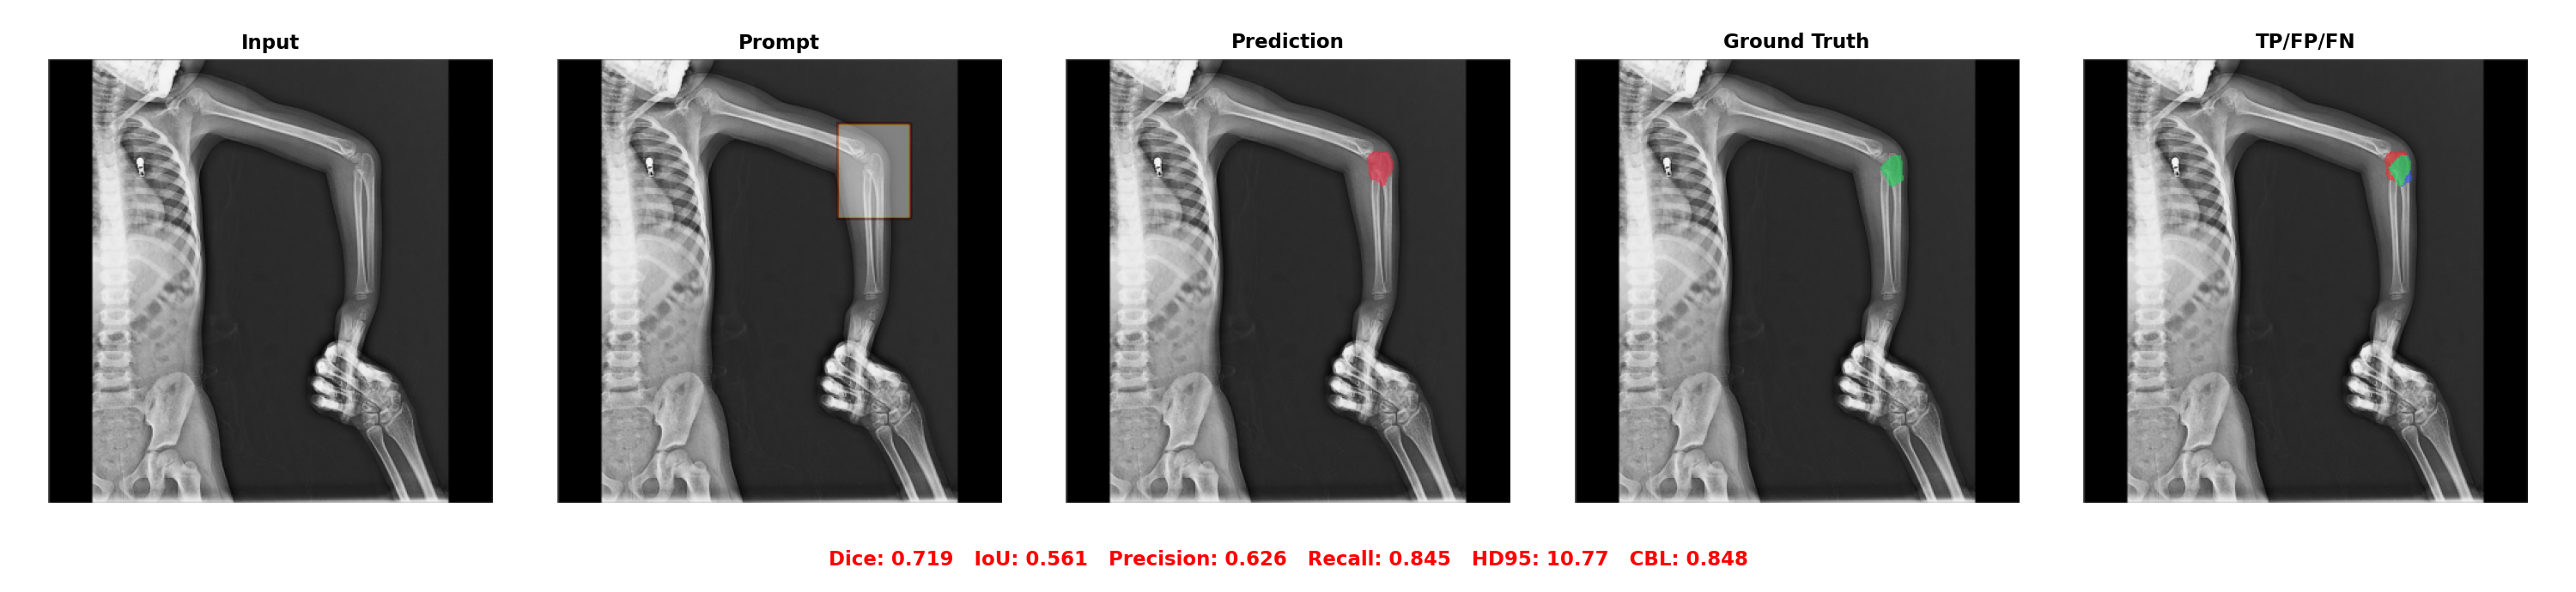

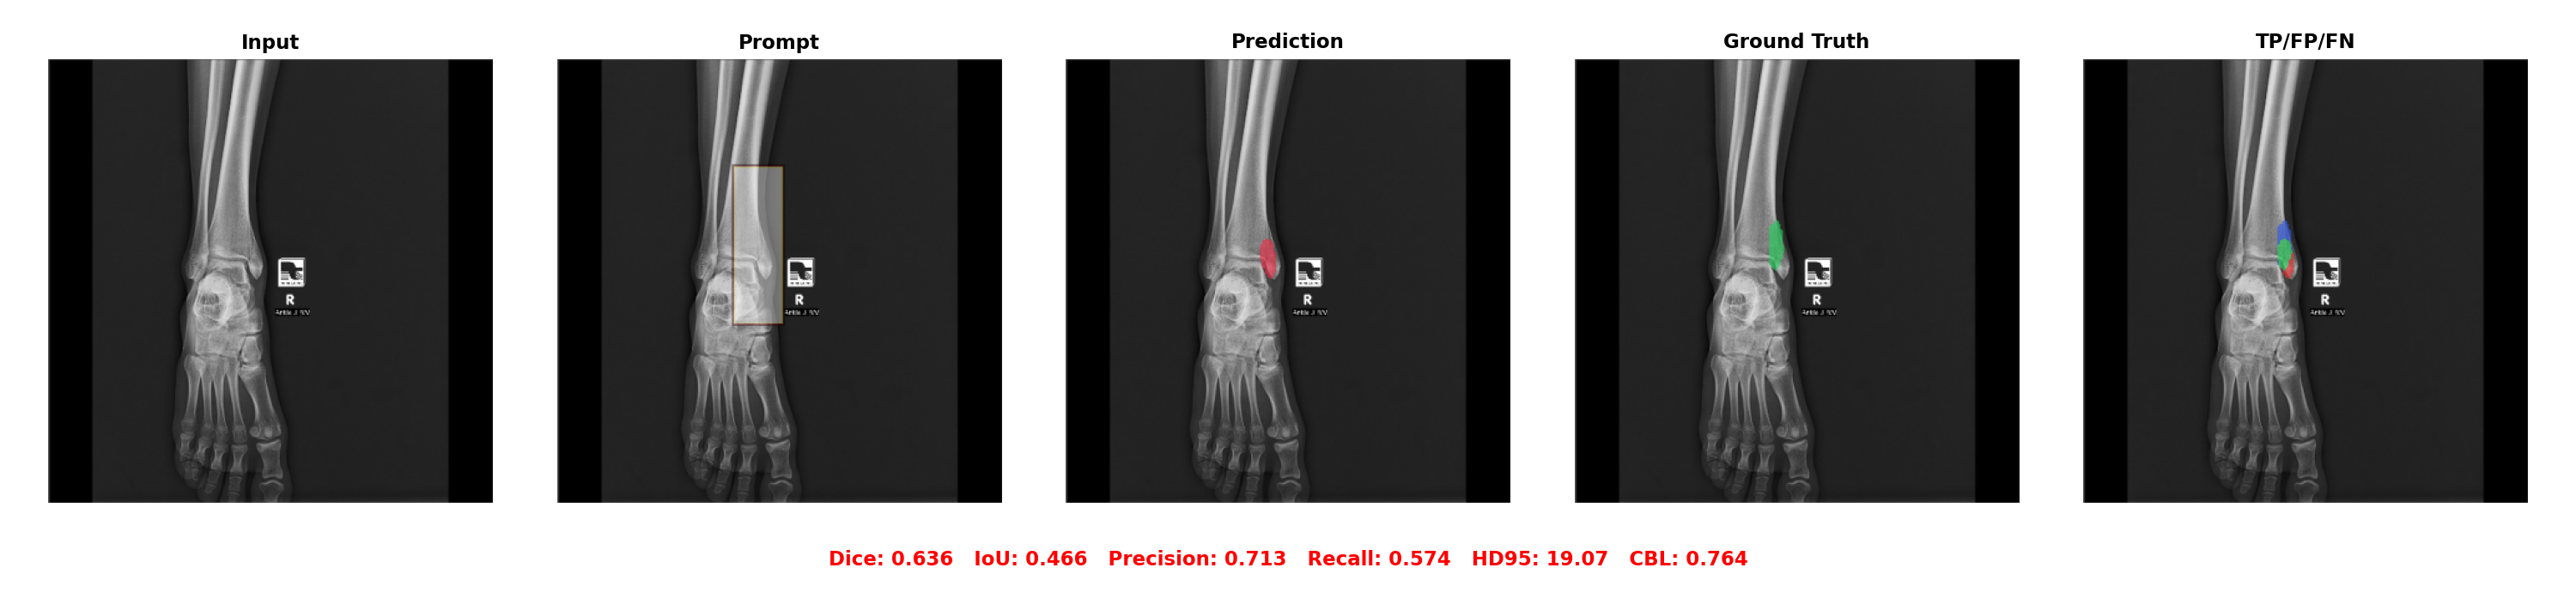

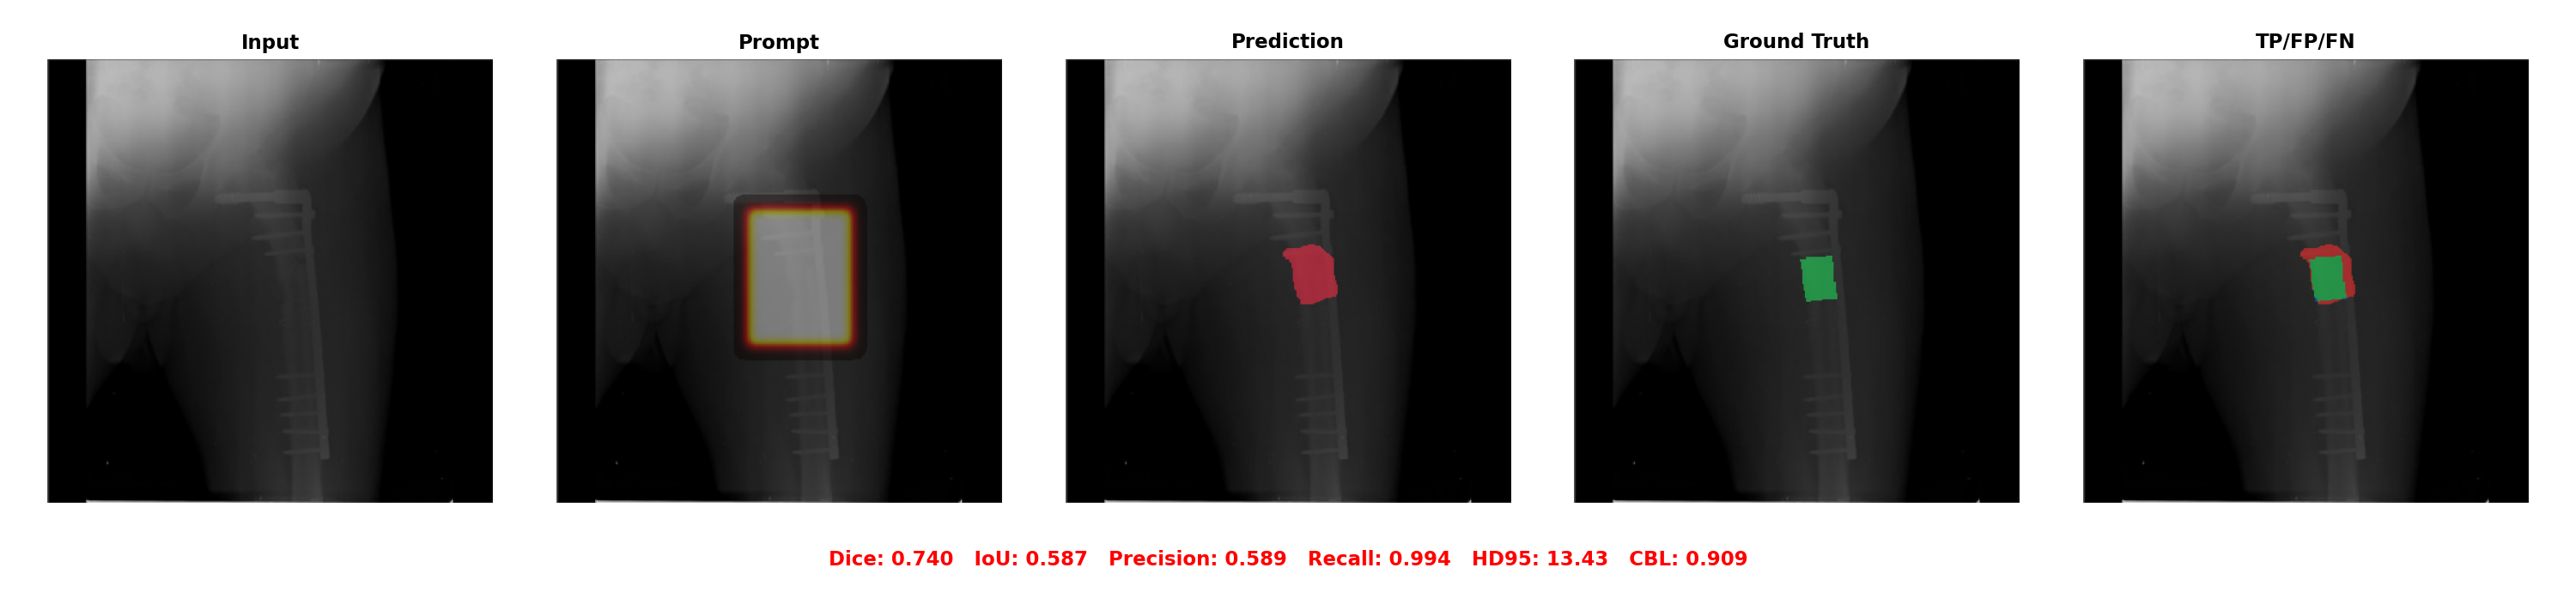

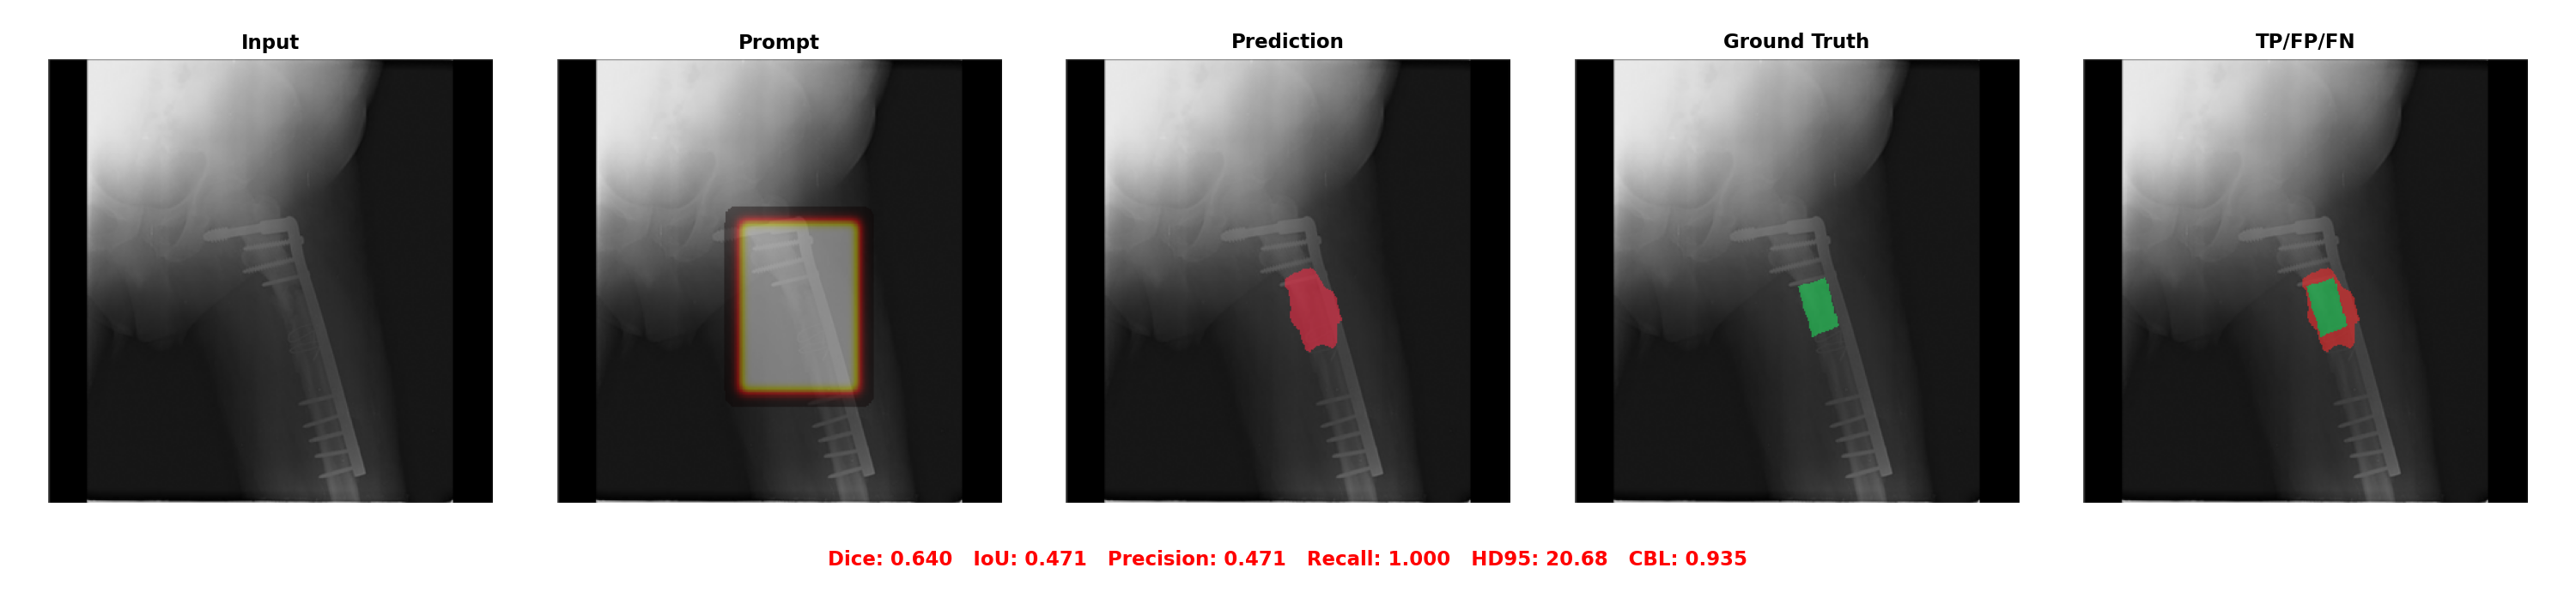

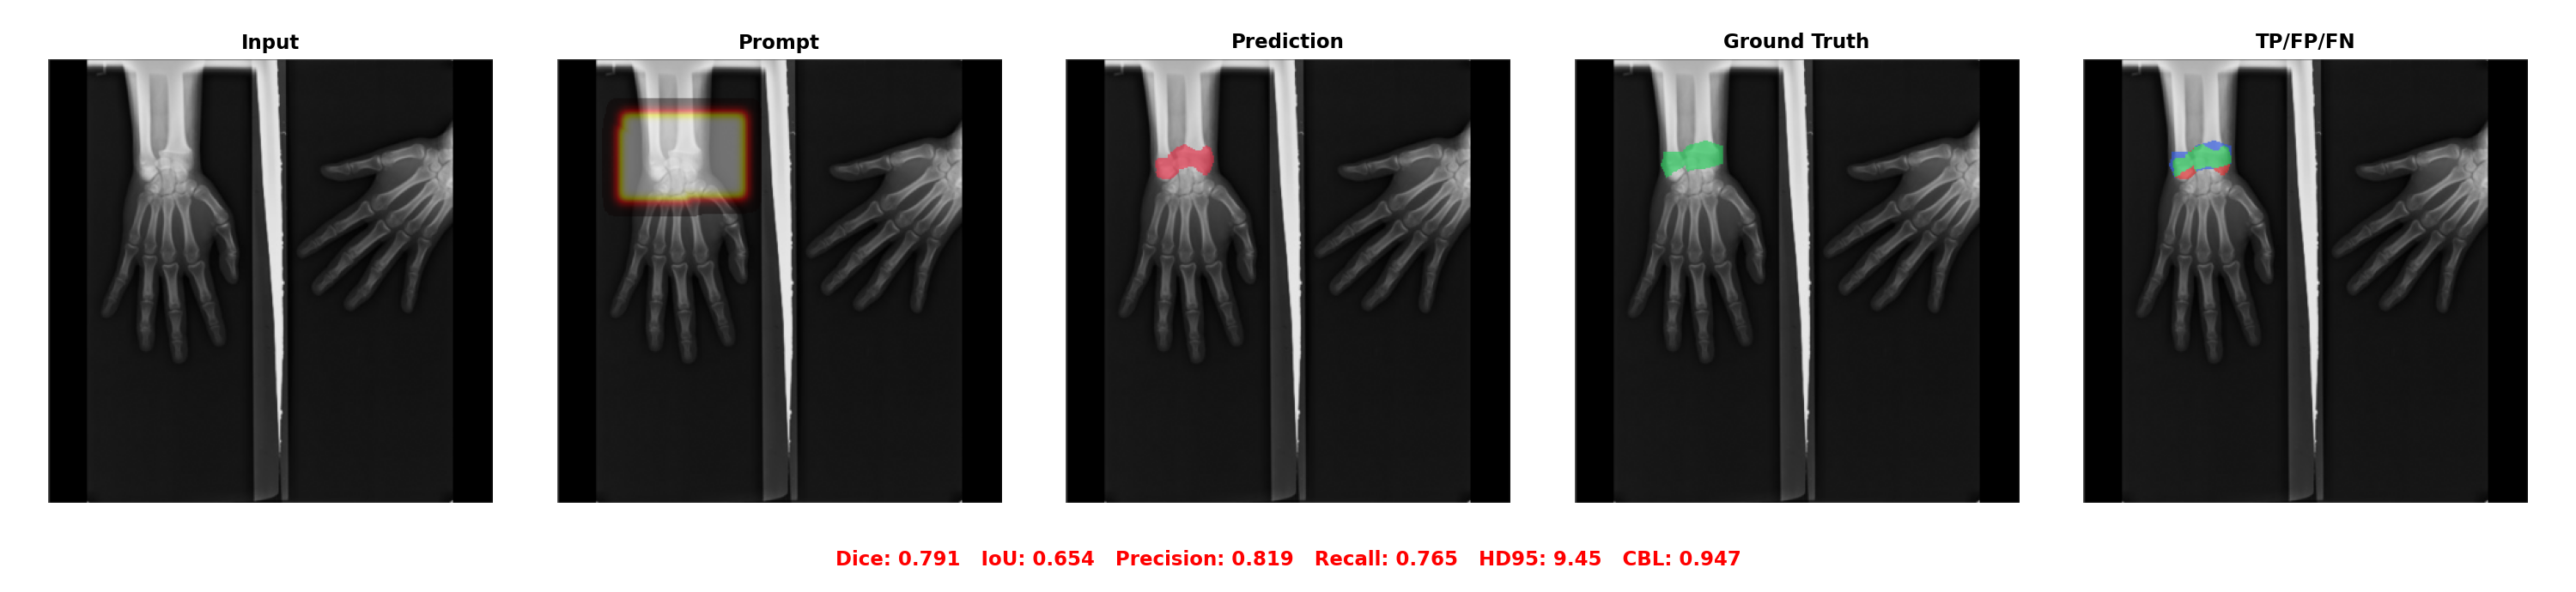

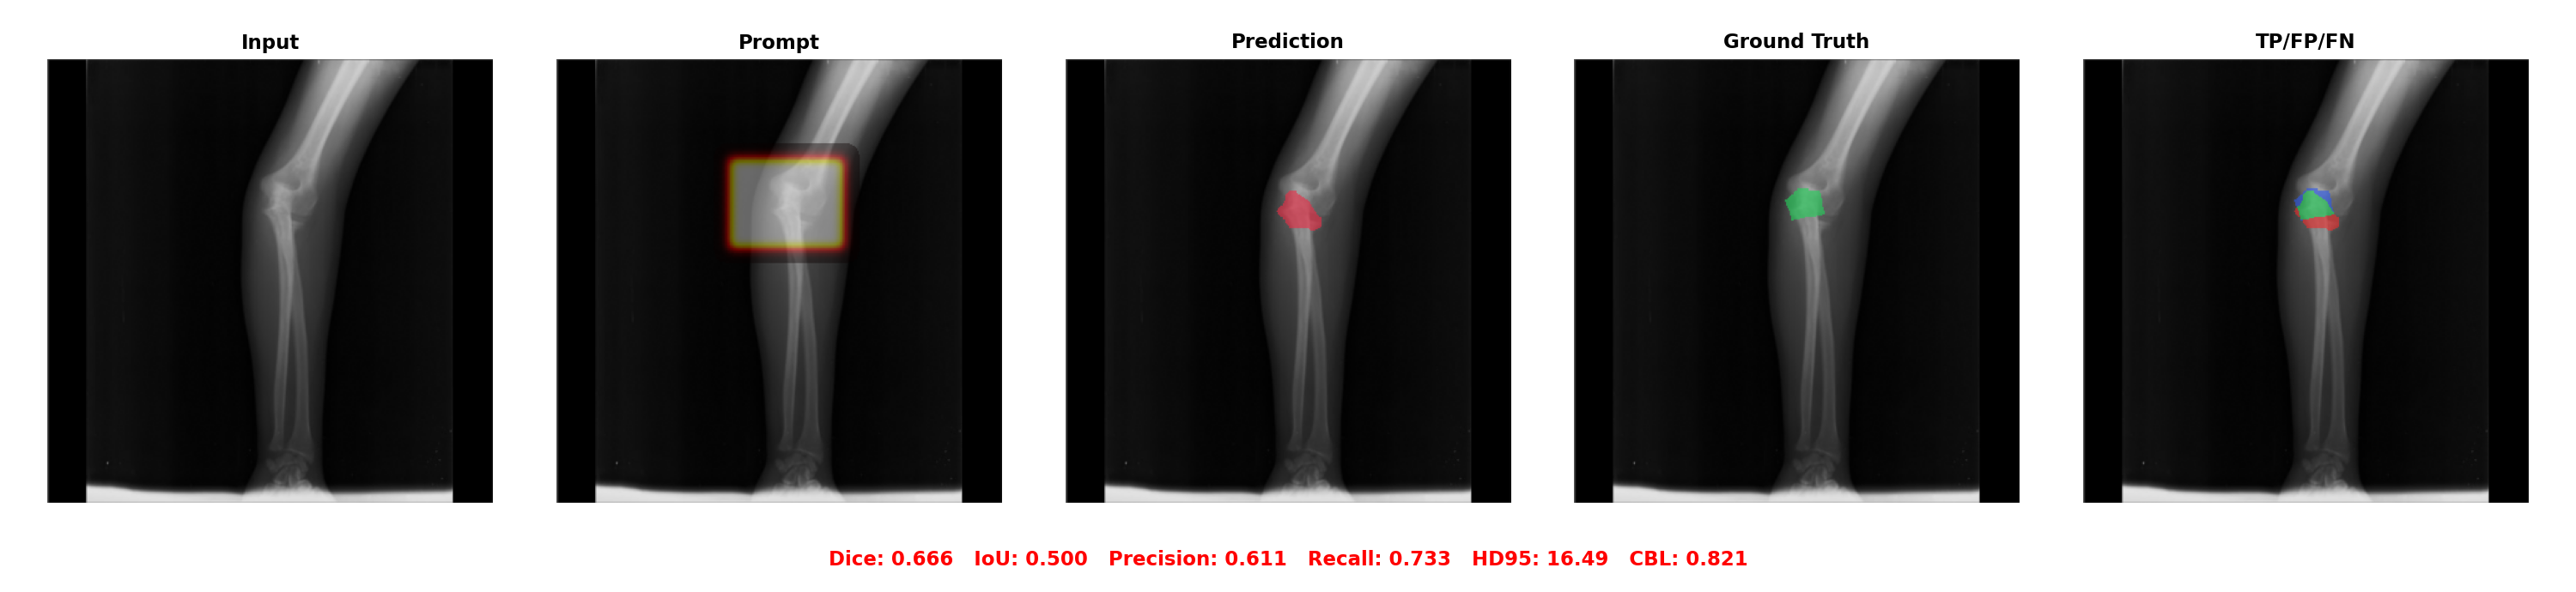

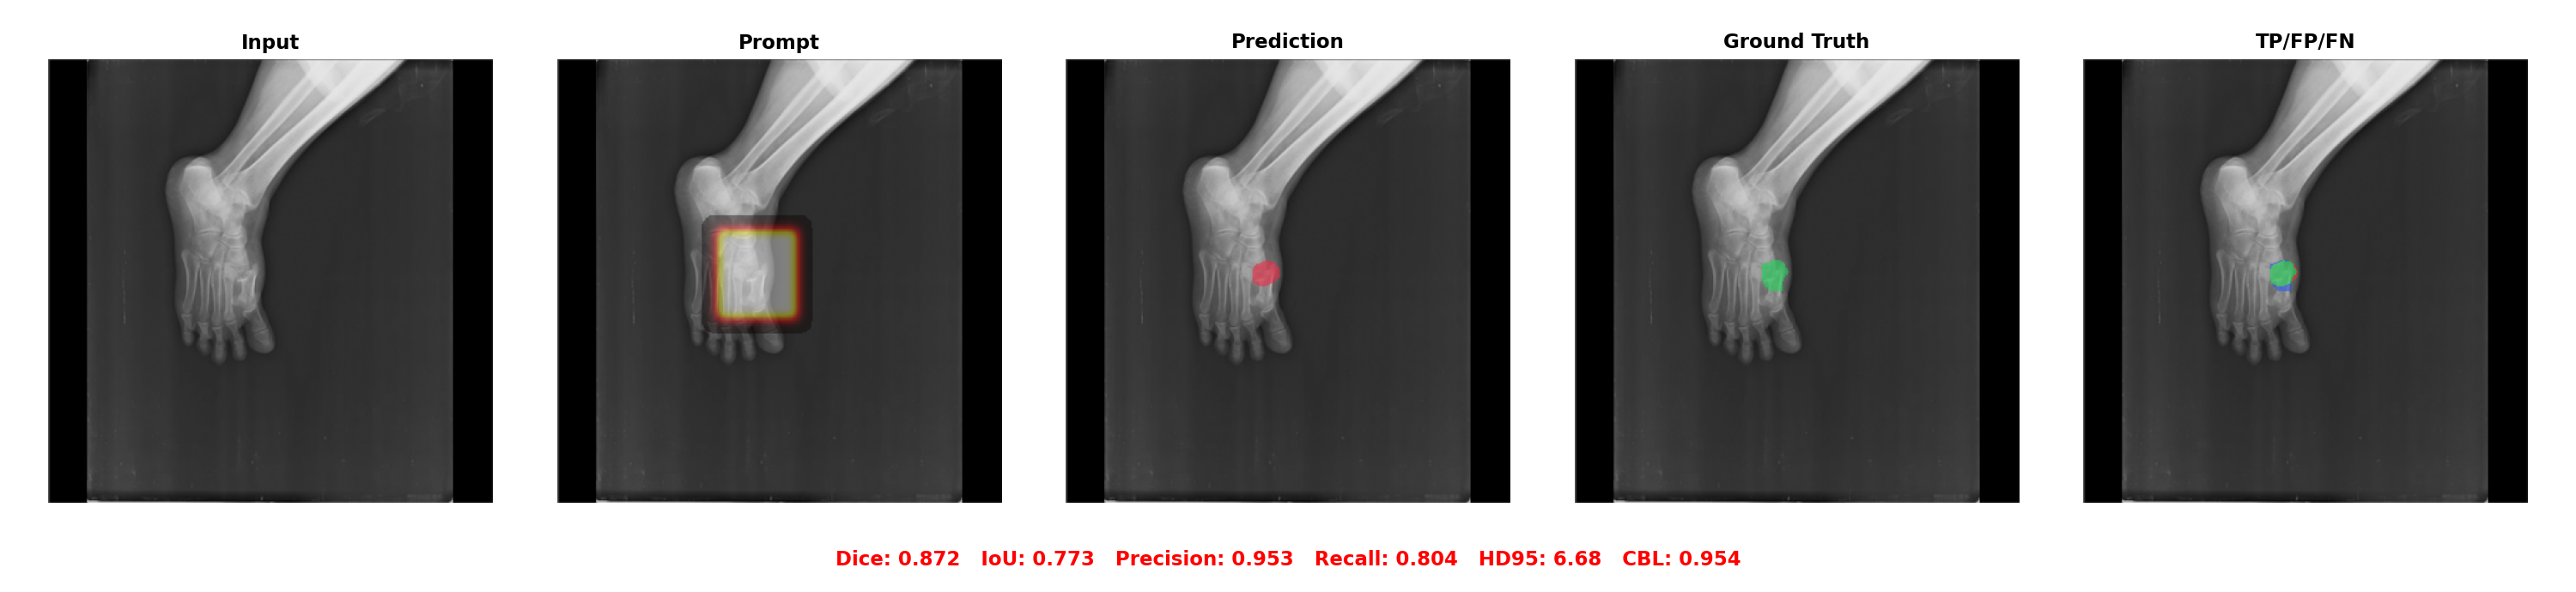

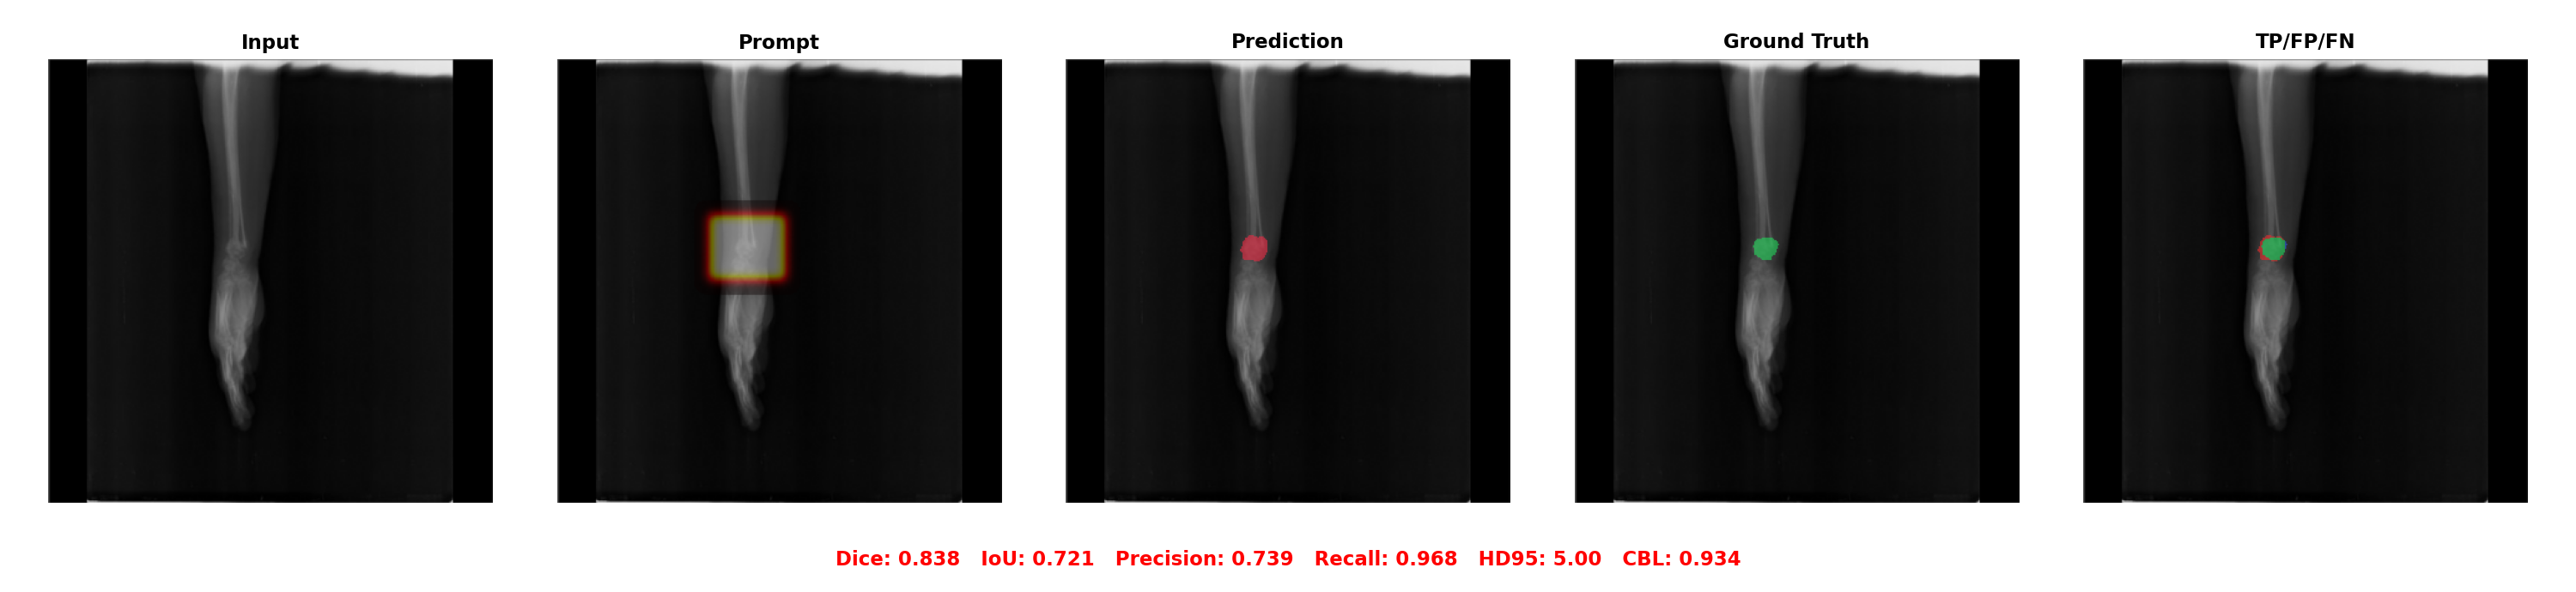

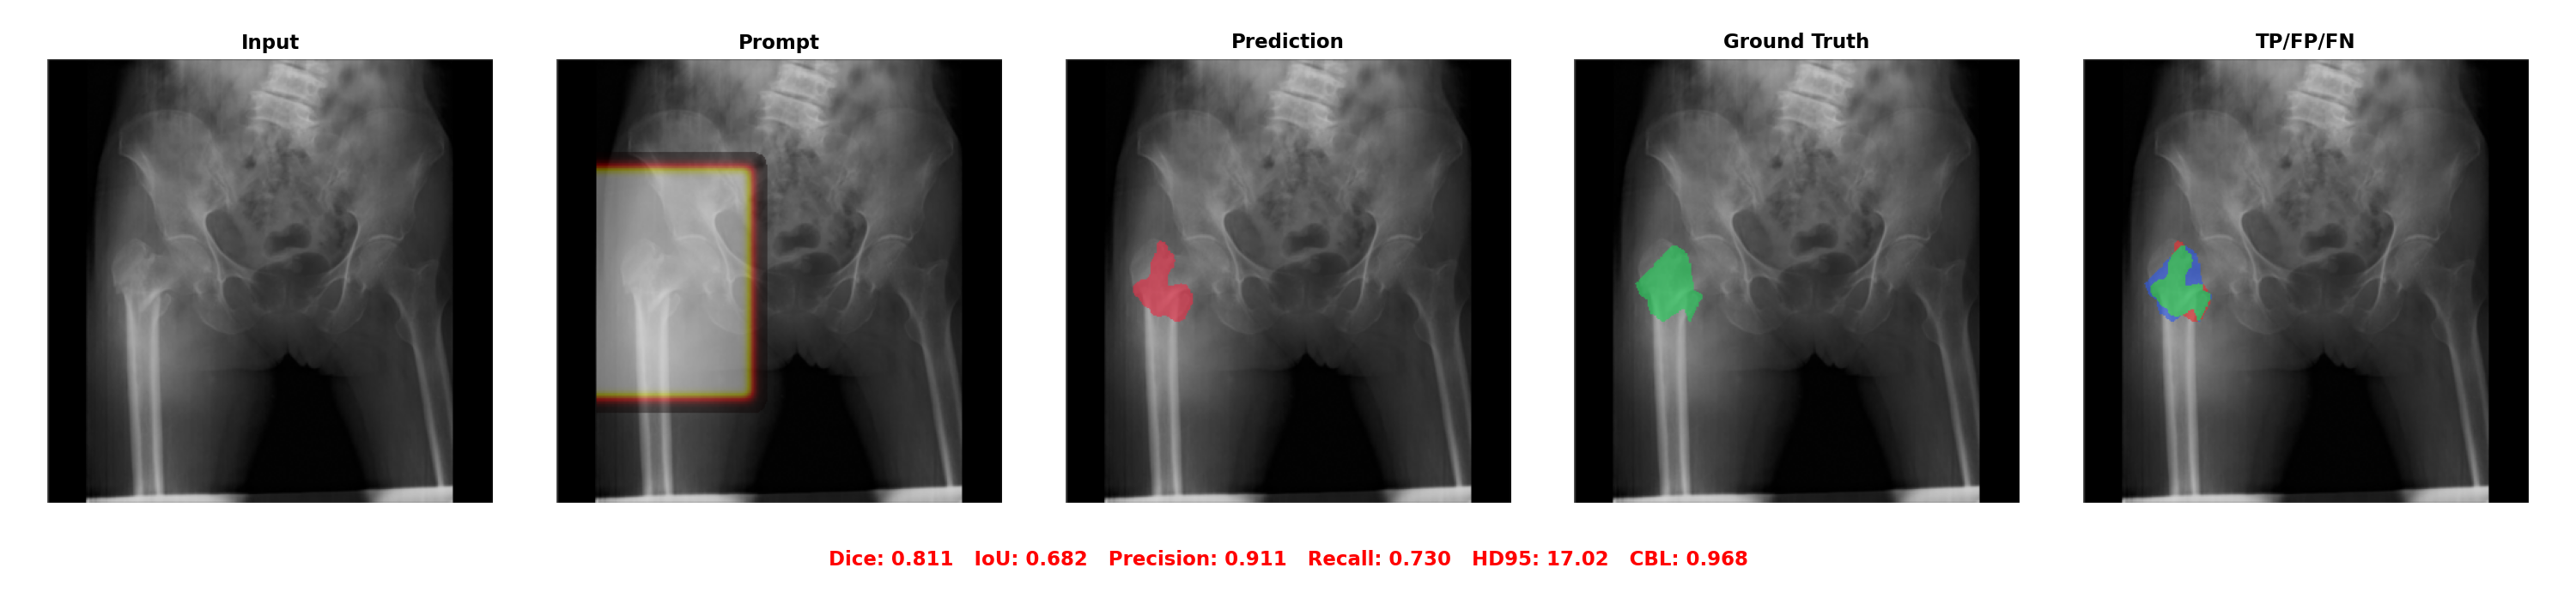

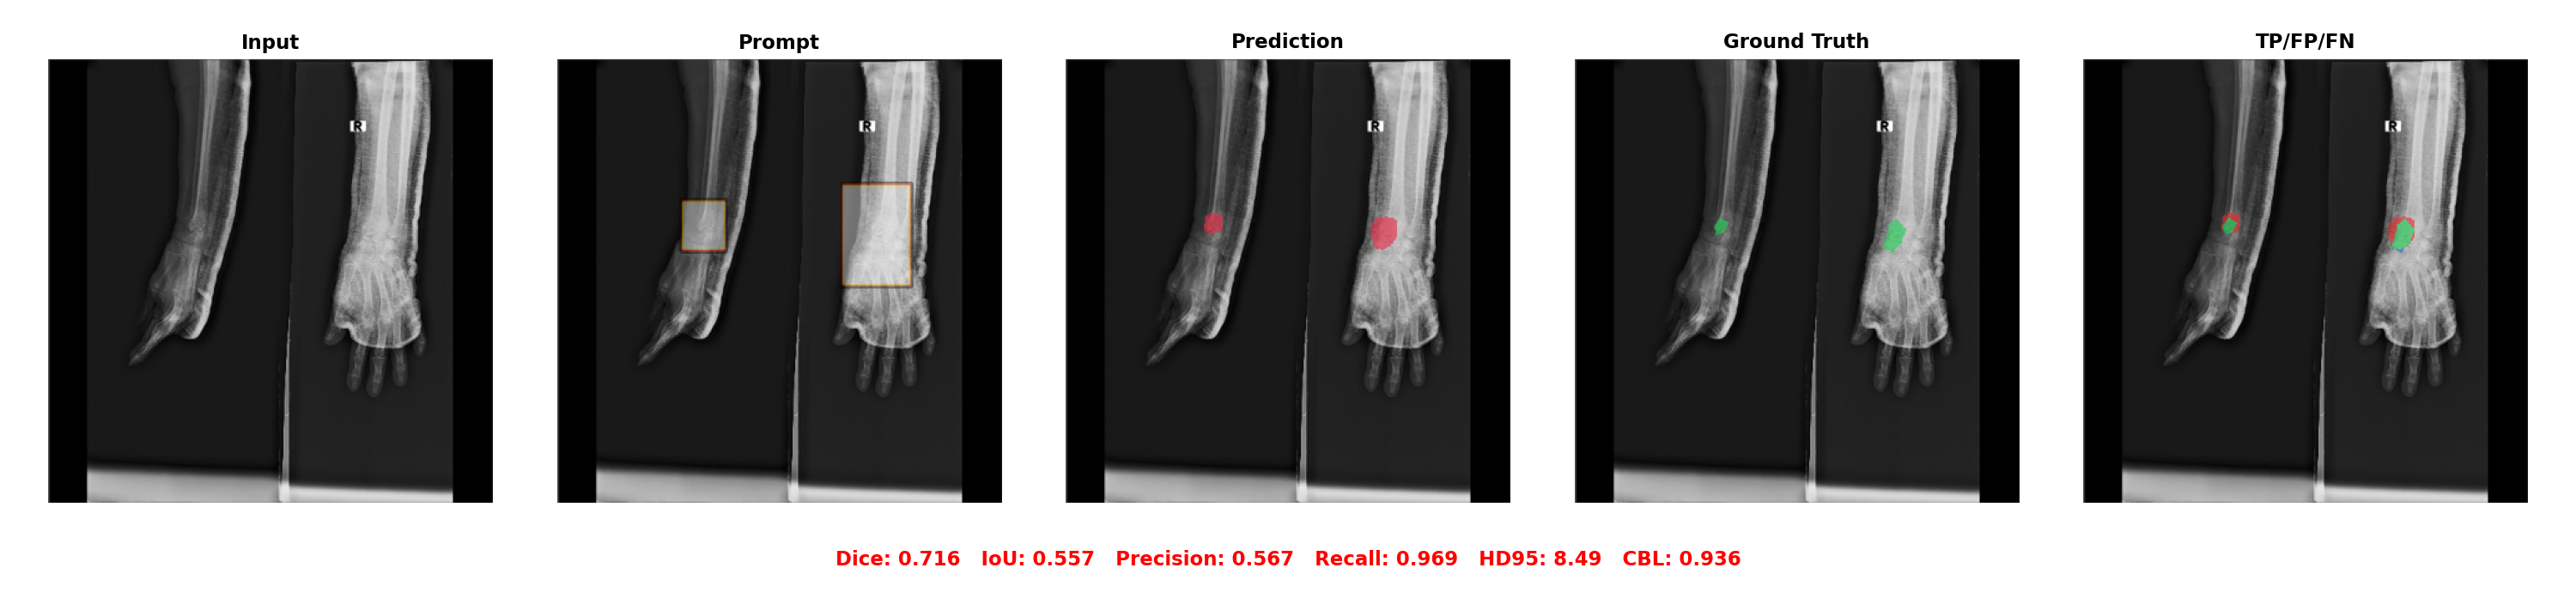

['results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_shared_5_multi-polygon_5_single-polygon_stems_01_IMG0000144.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_shared_5_multi-polygon_5_single-polygon_stems_02_IMG0000151.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_shared_5_multi-polygon_5_single-polygon_stems_03_IMG0000453.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_shared_5_multi-polygon_5_single-polygon_stems_04_IMG0000454.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_shared_5_multi-polygon_5_single-polygon_stems_05_IMG0001123.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_shared_5_multi-polygon_5_single-polygon_stems_06_IMG0001360.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_shared_5_multi-polygon_5_single-polygon_stems_07_IMG000

In [4]:
from qualitative_visualization import select_shared_stems, records_for_stems
from qualitative_visualization import export_qualitative_rows
# Balanced qualitative test stems: prefer 5 images with >=2 polygons and 5 images with 1 polygon.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

assert 'all_image_records' in dir(), '❌ Run the test cell first'
N_MULTI = 5
N_SINGLE = 5

ABLATION_BALANCED_TEST_STEMS = select_shared_stems(
    all_image_records['center_zoom'], N_MULTI, N_SINGLE)
recs = records_for_stems(all_image_records['center_zoom'], ABLATION_BALANCED_TEST_STEMS, context='qualitative records')
N_SHOW = len(recs)

fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
if N_SHOW == 1: axes = axes[np.newaxis, :]
fig.suptitle(f'{VARIANT_NAME} - {N_SHOW} balanced test images (shared 5 multi-polygon + 5 single-polygon stems)', fontsize=12, y=1.001)
col_titles = ['Input image', 'Image + prompts', 'Prediction (merged)', 'Ground truth', 'TP/FP/FN']
for ax, ct in zip(axes[0], col_titles): ax.set_title(ct, fontsize=10, fontweight='bold')
for count, rec in enumerate(recs):
    img_np = rec['img'] * 0.5 + 0.5
    gt_np = (rec['gt'] > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    prompt_merged = np.max(np.stack(rec['prompts'], axis=0), axis=0) if len(rec['prompts']) else np.zeros_like(gt_np)
    tp = (pred_np * gt_np).sum(); fp = (pred_np * (1 - gt_np)).sum(); fn = ((1 - pred_np) * gt_np).sum(); eps = 1e-6
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec_ = (tp + eps) / (tp + fn + eps)

    row = axes[count]
    bg = np.stack([img_np] * 3, axis=-1)
    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{rec["n_samples"]}p]\nDice={dice:.3f}', fontsize=8)
    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(np.where(prompt_merged>0,prompt_merged,np.nan), cmap='hot', alpha=0.35, vmin=0, vmax=1)
    row[2].imshow(bg); row[2].imshow(np.where(pred_np>0,pred_np,np.nan), cmap='Blues', alpha=0.60, vmin=0, vmax=1)
    row[3].imshow(bg); row[3].imshow(np.where(gt_np>0,gt_np,np.nan), cmap='Greens', alpha=0.60, vmin=0, vmax=1)
    overlay = np.zeros((*gt_np.shape, 3), dtype=float)
    overlay[..., 1] = pred_np * gt_np
    overlay[..., 0] = pred_np * (1 - gt_np)
    overlay[..., 2] = (1 - pred_np) * gt_np
    row[4].imshow(bg); row[4].imshow(overlay, alpha=0.75 * np.any(overlay > 0, axis=-1), vmin=0, vmax=1)
    row[4].text(0.02, 0.02, f'Dice={dice:.3f}\nIoU={iou:.3f}\nPrecision={prec:.3f}\nRecall={rec_:.3f}',
                transform=row[4].transAxes, fontsize=8, va='bottom', ha='left',
                bbox=dict(facecolor='black', alpha=0.45, pad=3, edgecolor='none'), color='white')
    for ax in row:
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))

handles = [Patch(facecolor='green', label='TP'), Patch(facecolor='red', label='FP'), Patch(facecolor='blue', label='FN')]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False)
plt.tight_layout(); plt.subplots_adjust(bottom=0.06)
export_qualitative_rows(fig, axes, recs)

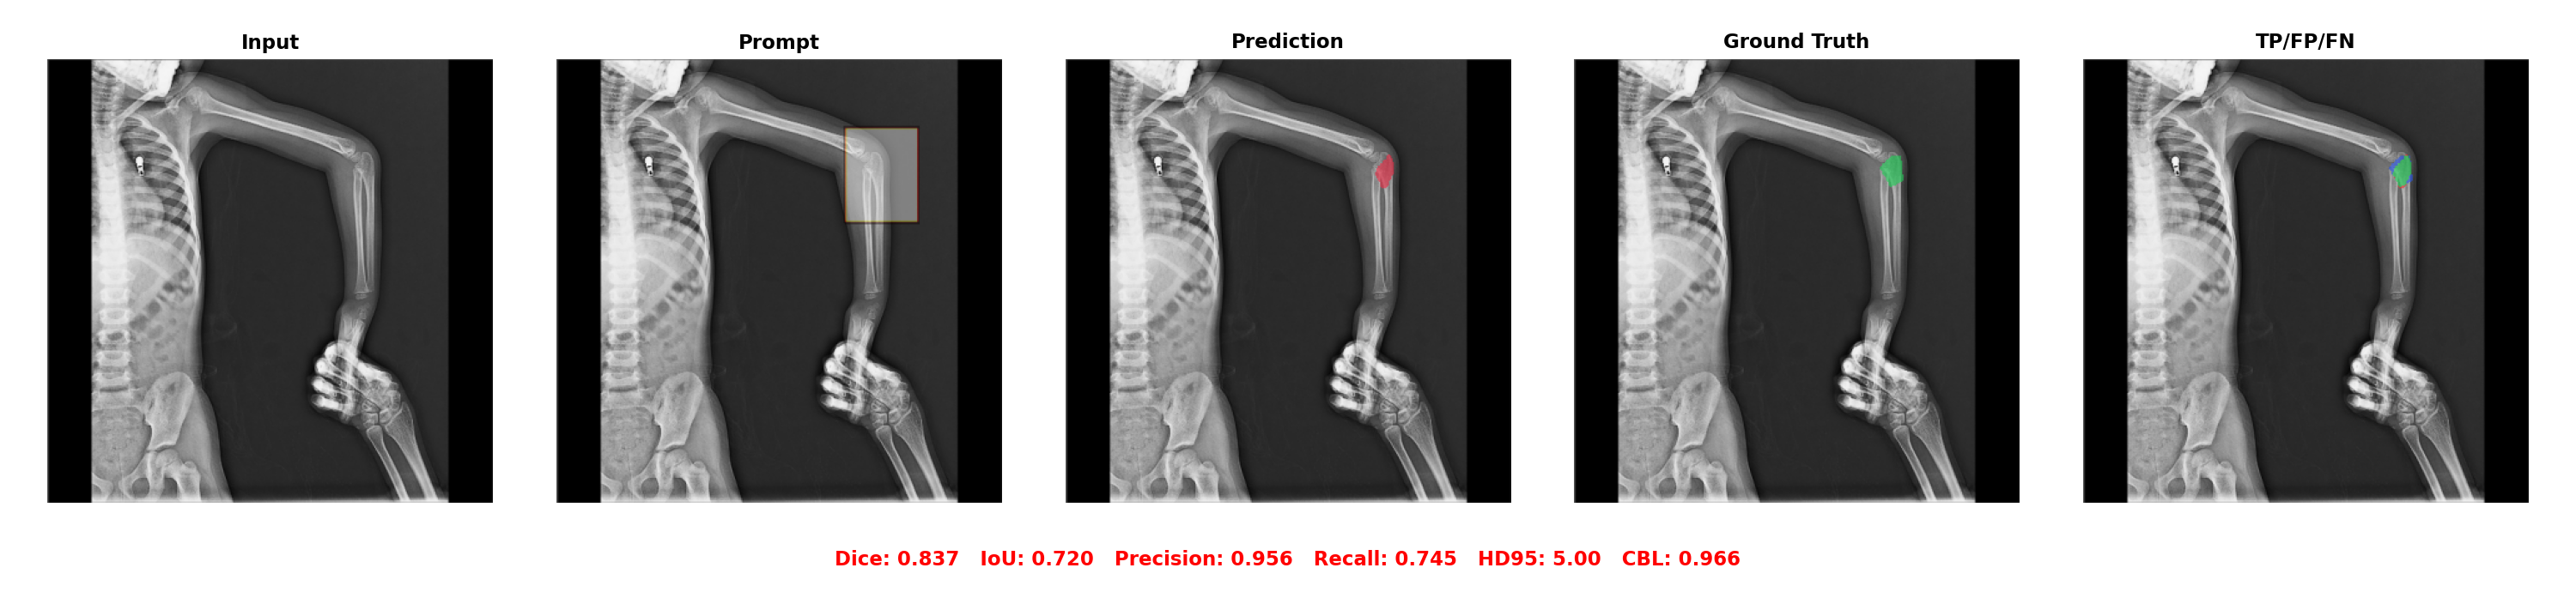

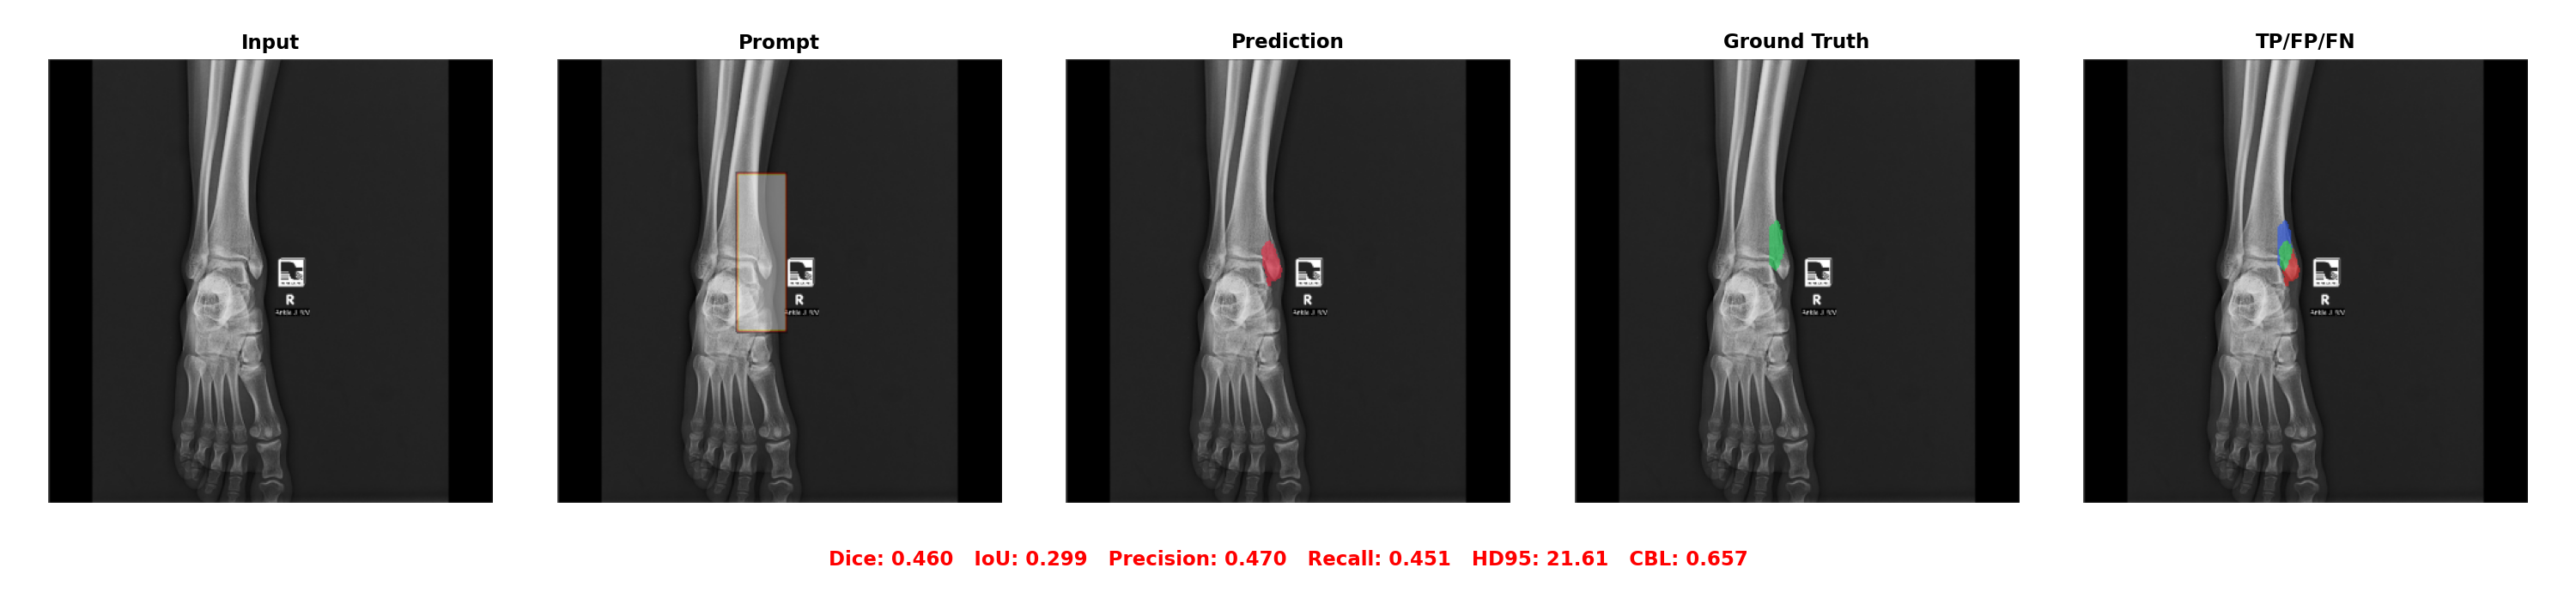

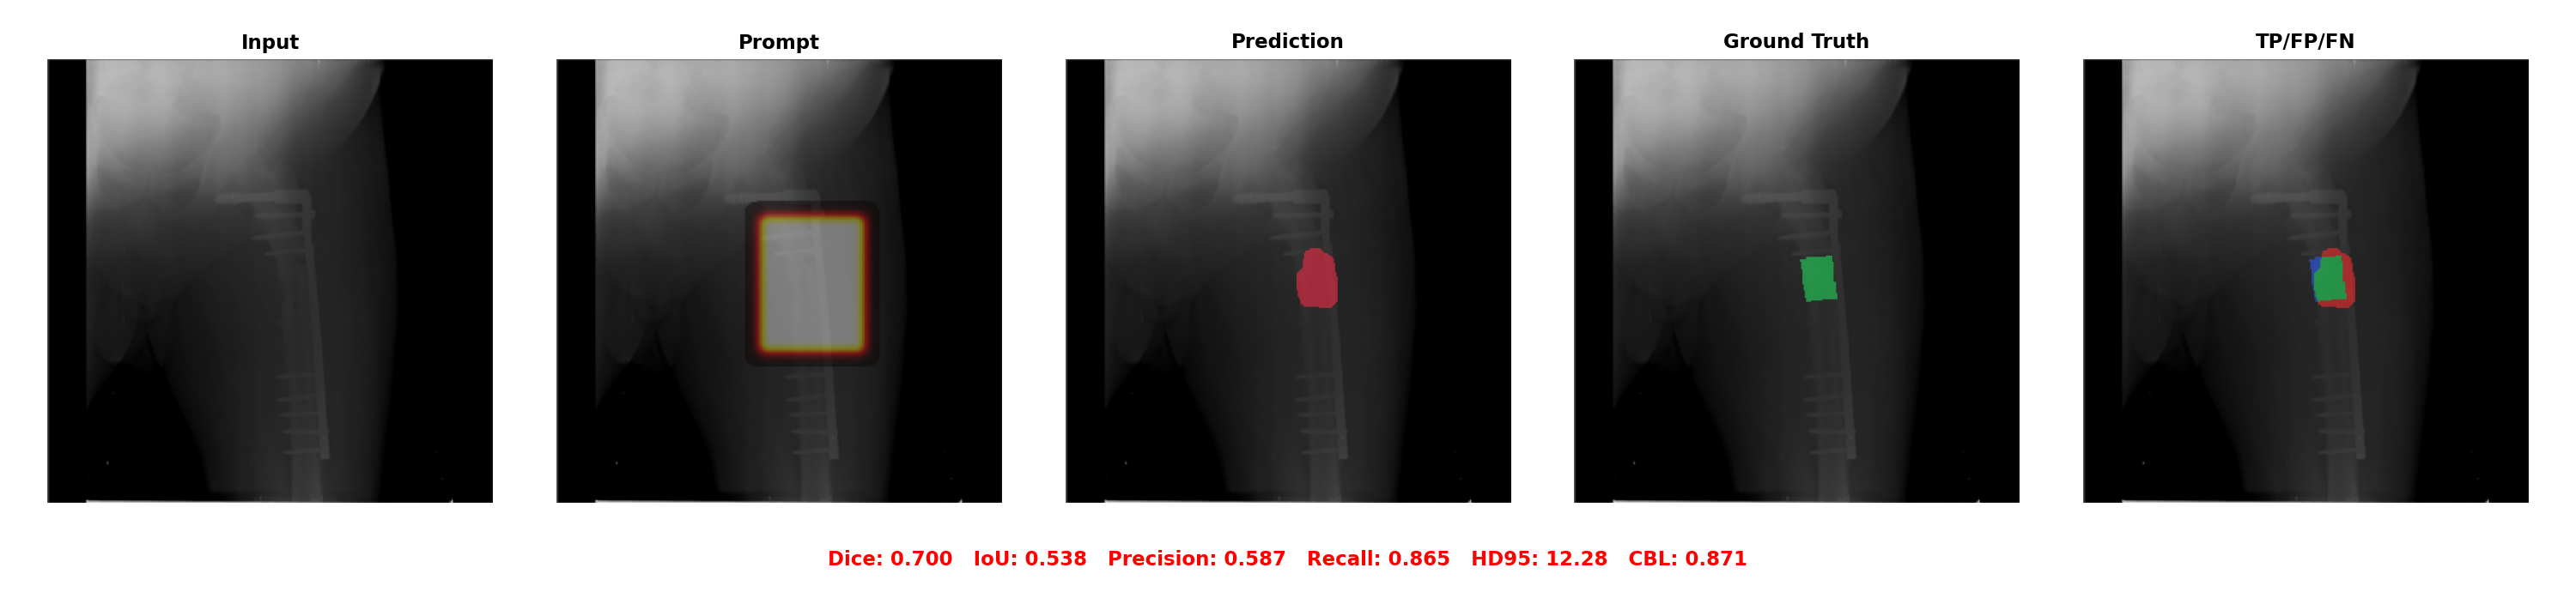

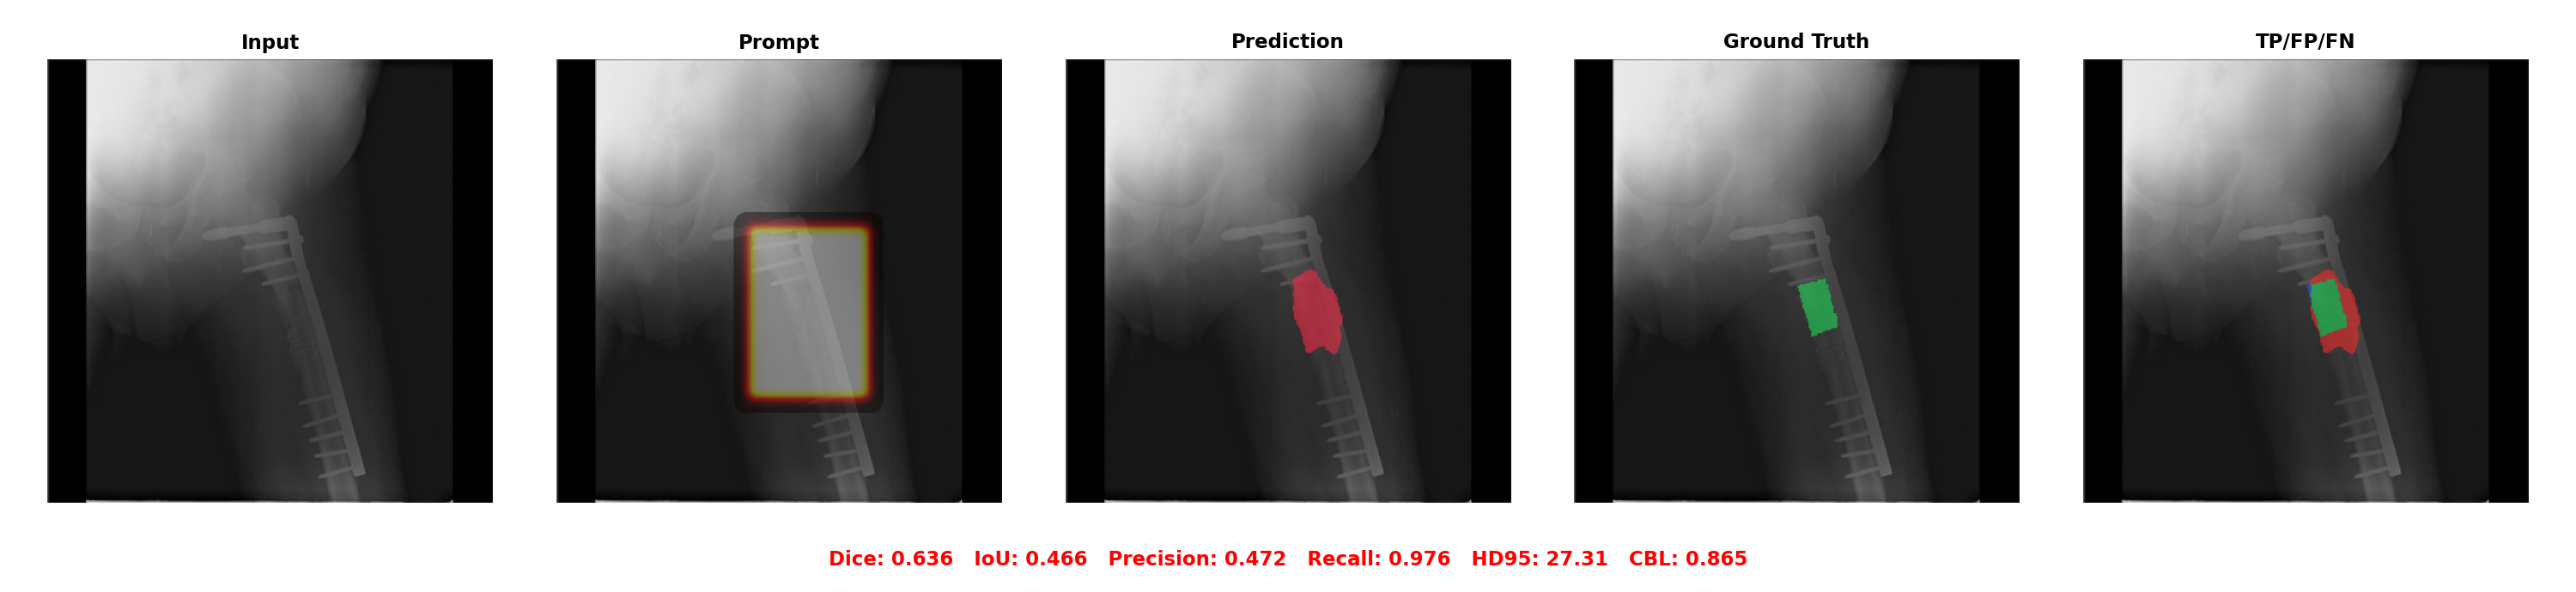

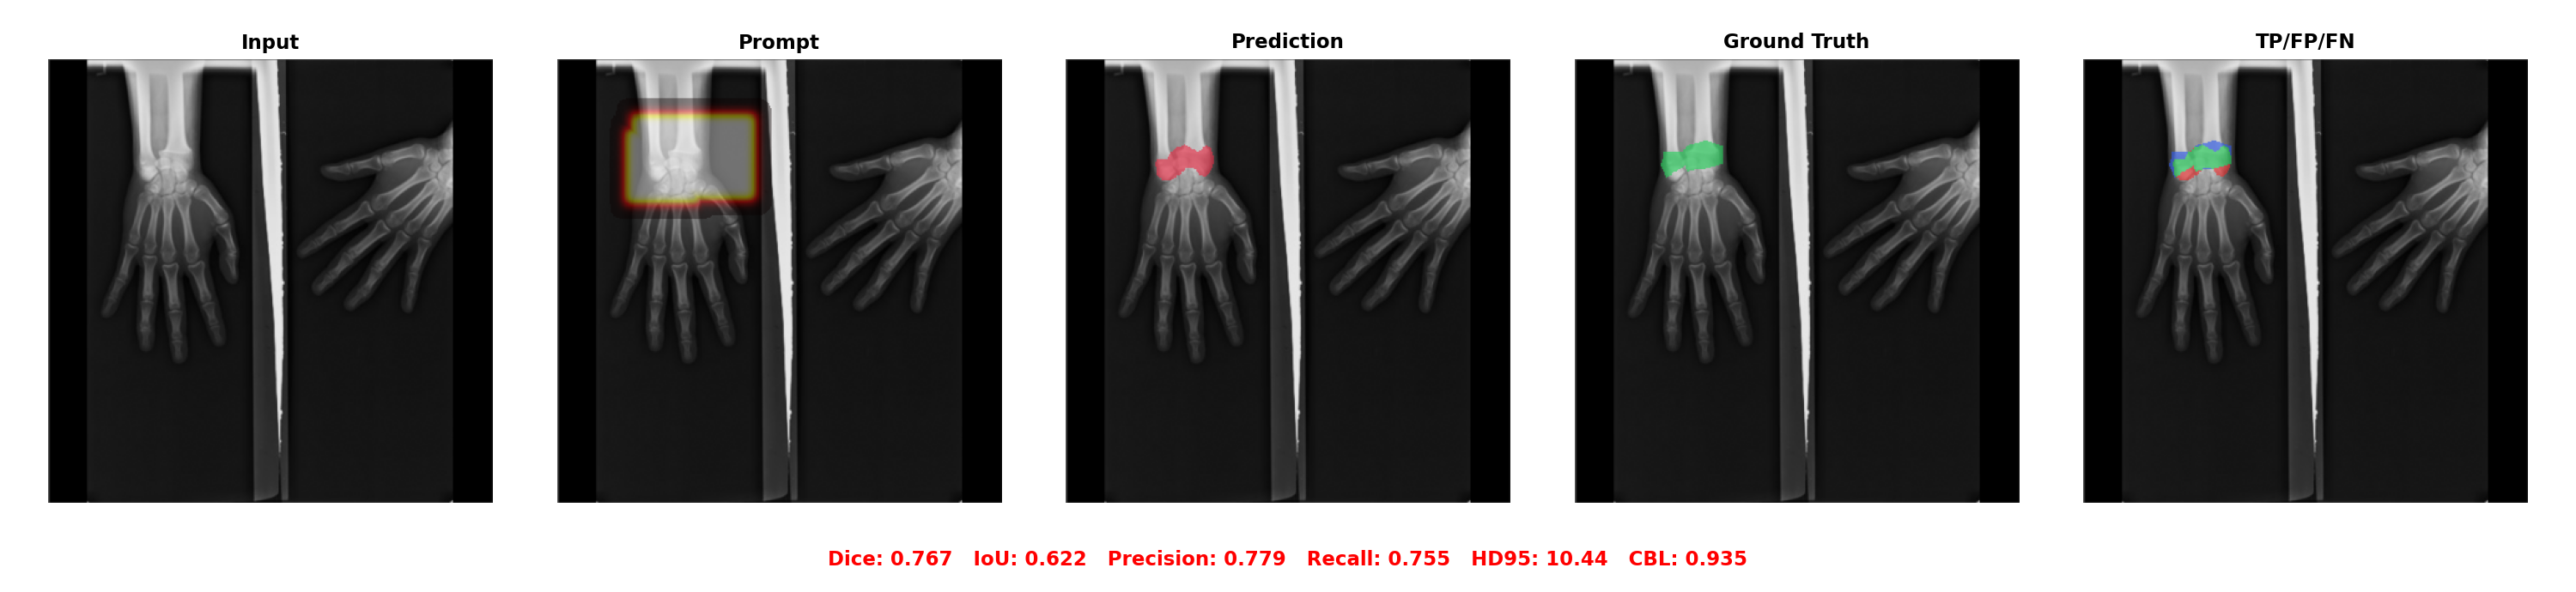

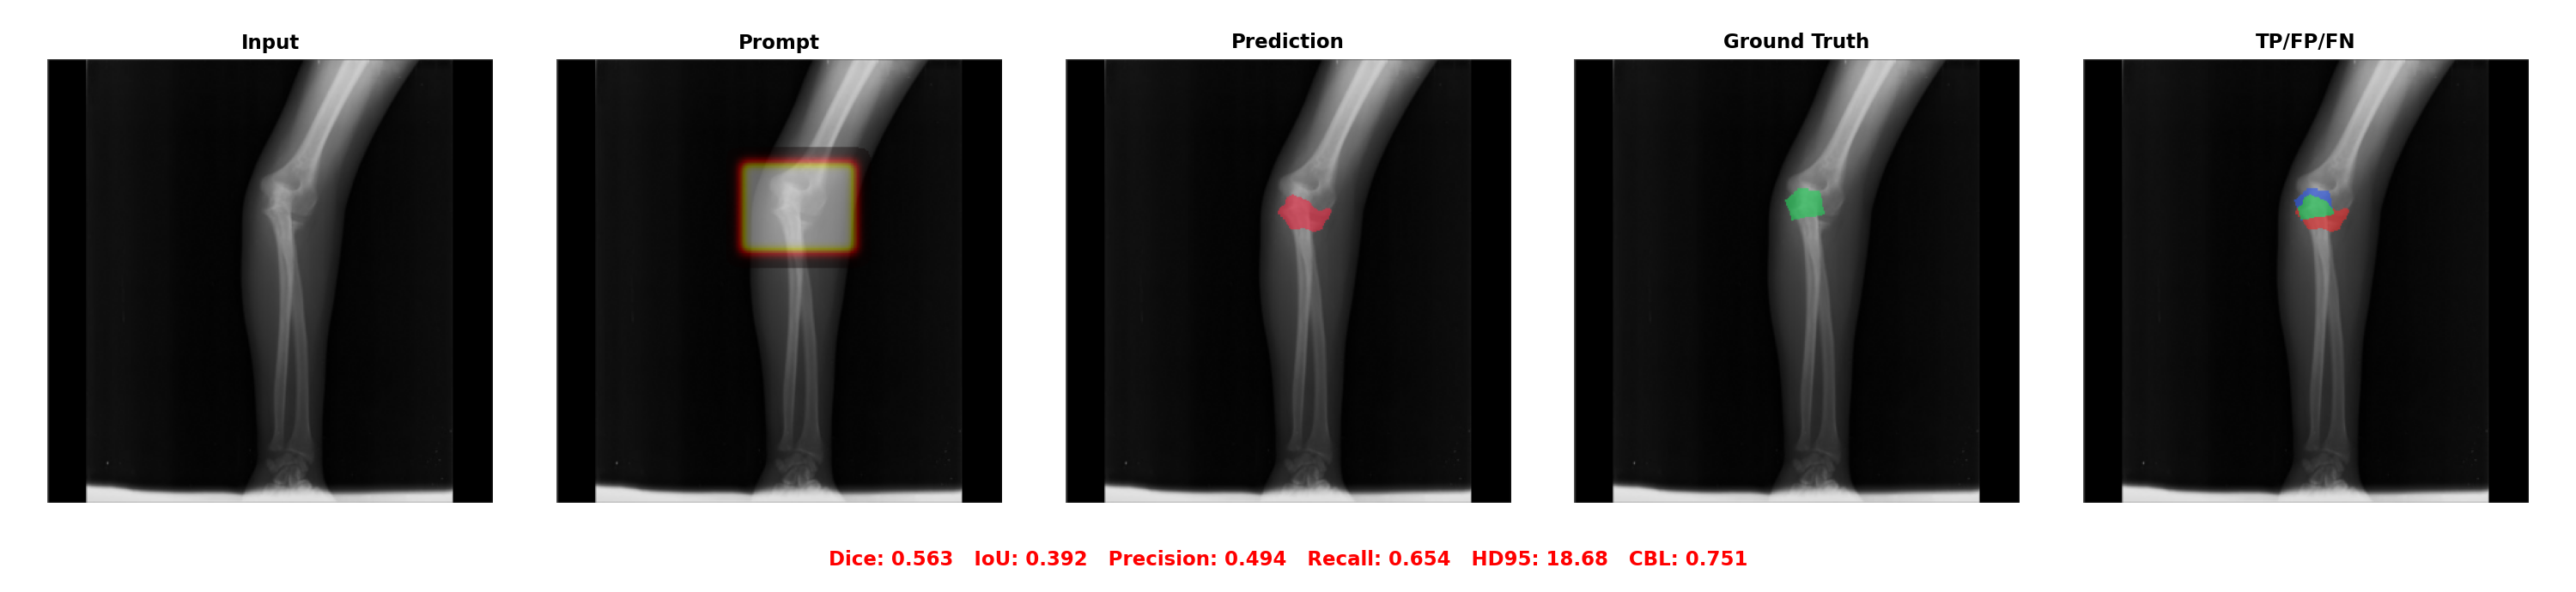

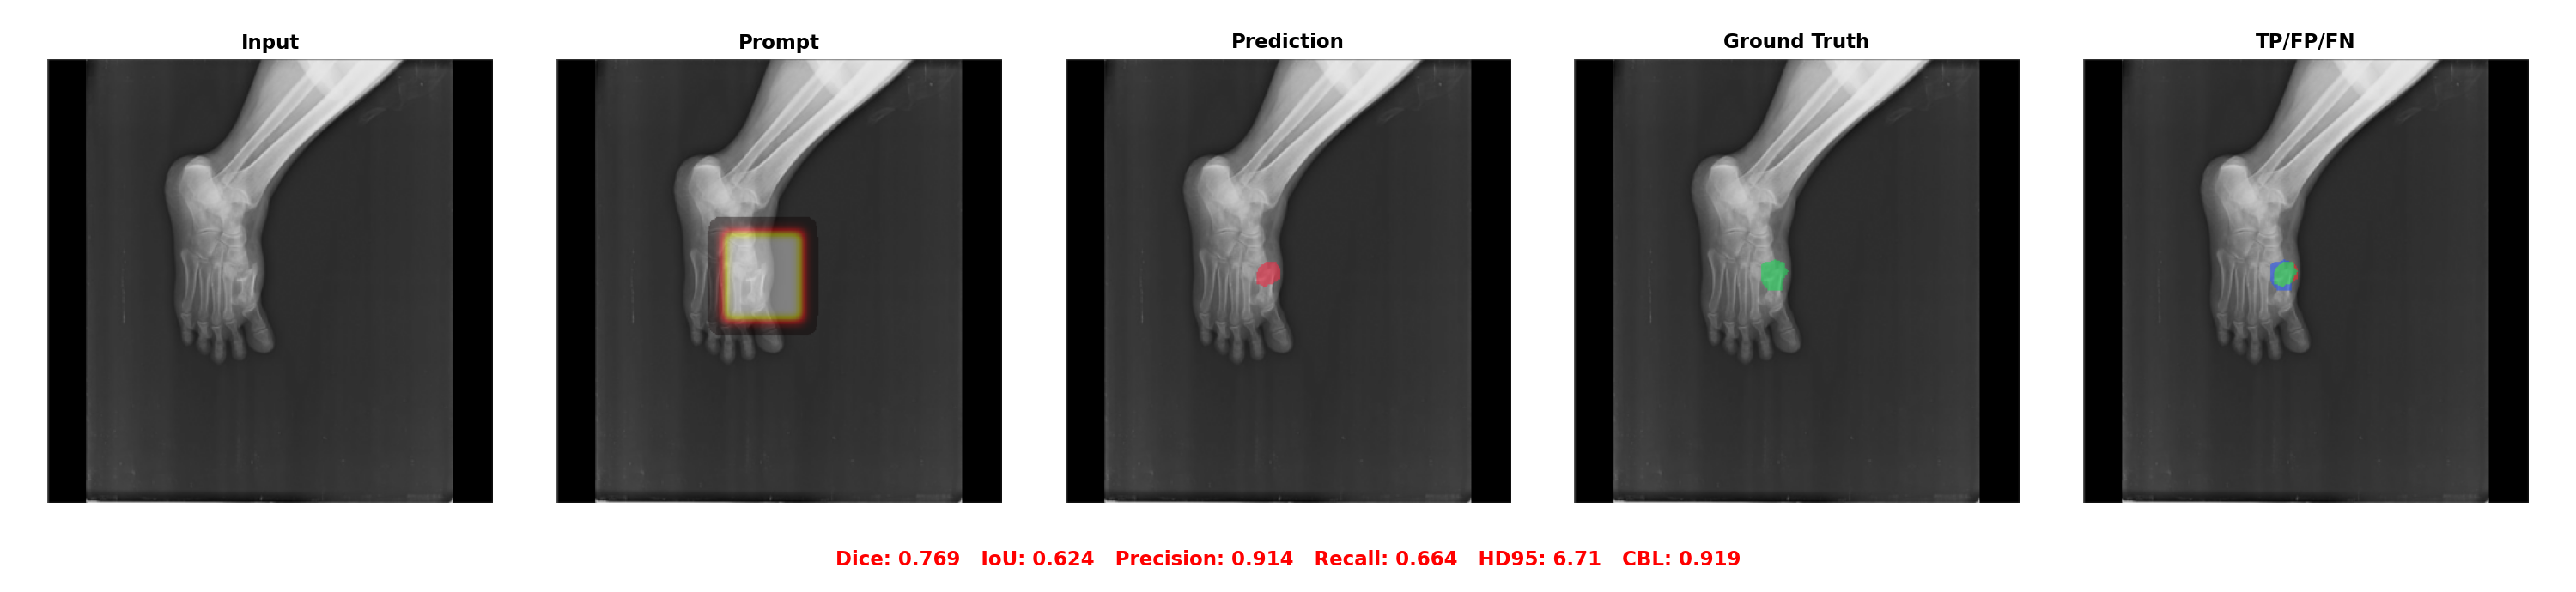

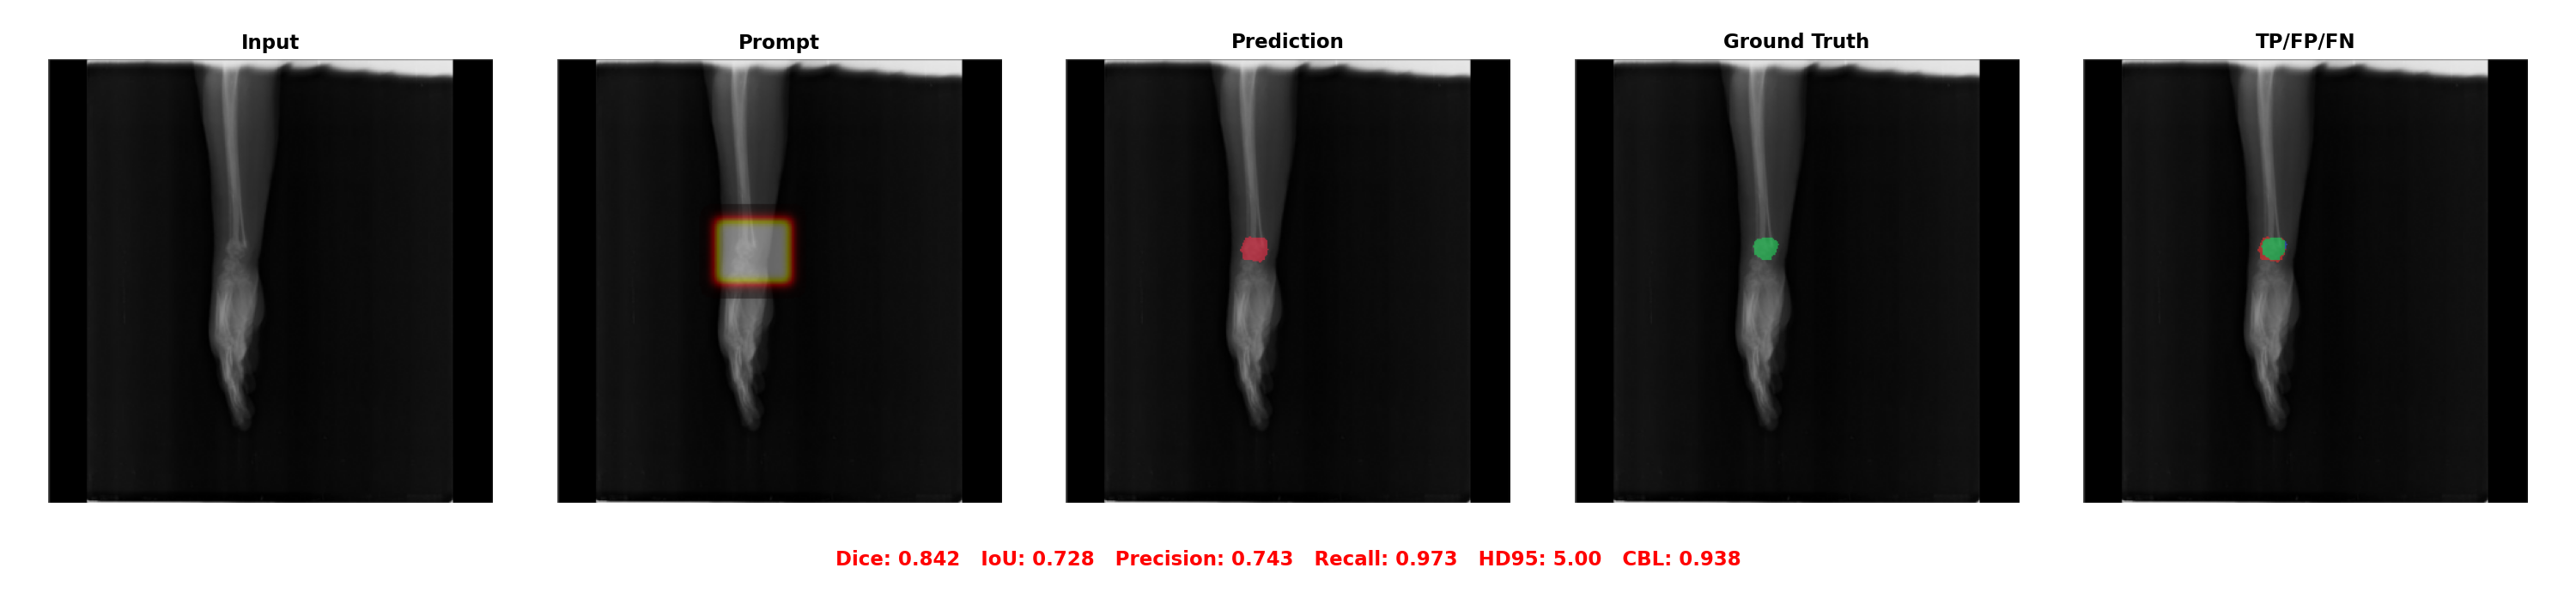

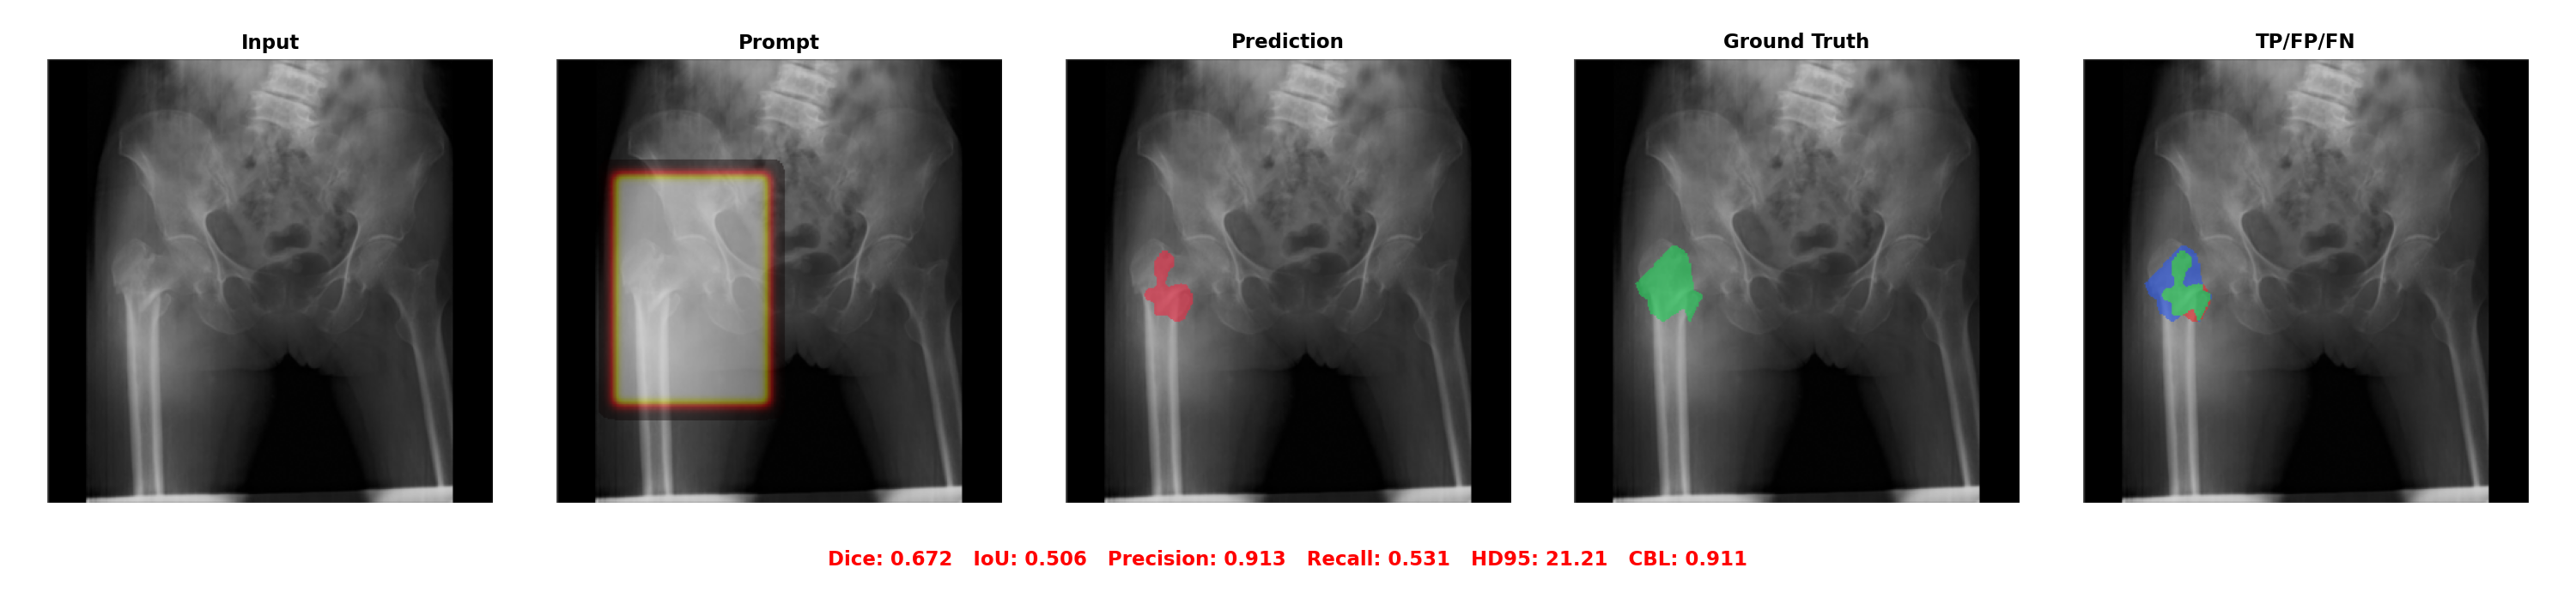

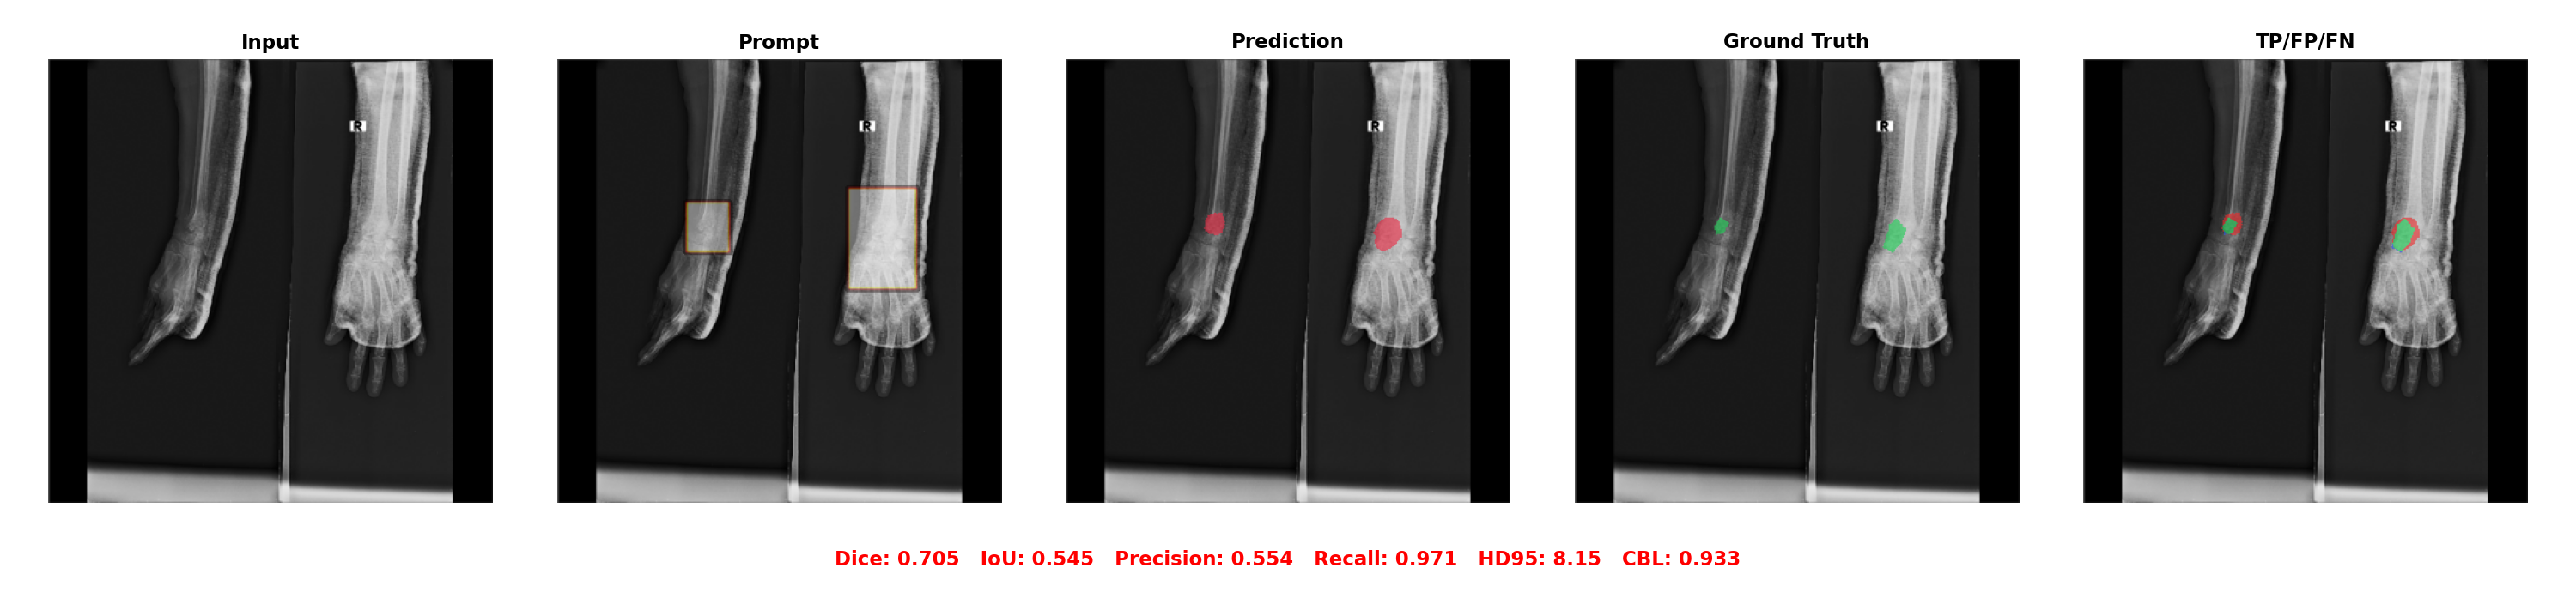

['results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_center_shift_shared_5_multi-polygon_5_single-polygon_stems_01_IMG0000144.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_center_shift_shared_5_multi-polygon_5_single-polygon_stems_02_IMG0000151.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_center_shift_shared_5_multi-polygon_5_single-polygon_stems_03_IMG0000453.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_center_shift_shared_5_multi-polygon_5_single-polygon_stems_04_IMG0000454.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_center_shift_shared_5_multi-polygon_5_single-polygon_stems_05_IMG0001123.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_10_balanced_test_images_center_shift_shared_5_multi-polygon_5_single-polygon_stems_06_IMG0001360.png.png',
 'results/qualitative/Full_PGA_Heatmap_reference_-_1

In [5]:
from qualitative_visualization import select_shared_stems, records_for_stems
from qualitative_visualization import export_qualitative_rows
# Balanced qualitative test stems: prefer 5 images with >=2 polygons and 5 images with 1 polygon.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

assert 'all_image_records' in dir(), '❌ Run the test cell first'
N_MULTI = 5
N_SINGLE = 5

ABLATION_BALANCED_TEST_STEMS = select_shared_stems(
    all_image_records['center_zoom'], N_MULTI, N_SINGLE)
recs = records_for_stems(all_image_records['center_shift'], ABLATION_BALANCED_TEST_STEMS, context='qualitative records')
N_SHOW = len(recs)

fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
if N_SHOW == 1: axes = axes[np.newaxis, :]
fig.suptitle(f'{VARIANT_NAME} - {N_SHOW} balanced test images (center_shift) (shared 5 multi-polygon + 5 single-polygon stems)', fontsize=12, y=1.001)
col_titles = ['Input image', 'Image + prompts', 'Prediction (merged)', 'Ground truth', 'TP/FP/FN']
for ax, ct in zip(axes[0], col_titles): ax.set_title(ct, fontsize=10, fontweight='bold')
for count, rec in enumerate(recs):
    img_np = rec['img'] * 0.5 + 0.5
    gt_np = (rec['gt'] > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    prompt_merged = np.max(np.stack(rec['prompts'], axis=0), axis=0) if len(rec['prompts']) else np.zeros_like(gt_np)
    tp = (pred_np * gt_np).sum(); fp = (pred_np * (1 - gt_np)).sum(); fn = ((1 - pred_np) * gt_np).sum(); eps = 1e-6
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec_ = (tp + eps) / (tp + fn + eps)

    row = axes[count]
    bg = np.stack([img_np] * 3, axis=-1)
    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{rec["n_samples"]}p]\nDice={dice:.3f}', fontsize=8)
    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(np.where(prompt_merged>0,prompt_merged,np.nan), cmap='hot', alpha=0.35, vmin=0, vmax=1)
    row[2].imshow(bg); row[2].imshow(np.where(pred_np>0,pred_np,np.nan), cmap='Blues', alpha=0.60, vmin=0, vmax=1)
    row[3].imshow(bg); row[3].imshow(np.where(gt_np>0,gt_np,np.nan), cmap='Greens', alpha=0.60, vmin=0, vmax=1)
    overlay = np.zeros((*gt_np.shape, 3), dtype=float)
    overlay[..., 1] = pred_np * gt_np
    overlay[..., 0] = pred_np * (1 - gt_np)
    overlay[..., 2] = (1 - pred_np) * gt_np
    row[4].imshow(bg); row[4].imshow(overlay, alpha=0.75 * np.any(overlay > 0, axis=-1), vmin=0, vmax=1)
    row[4].text(0.02, 0.02, f'Dice={dice:.3f}\nIoU={iou:.3f}\nPrecision={prec:.3f}\nRecall={rec_:.3f}',
                transform=row[4].transAxes, fontsize=8, va='bottom', ha='left',
                bbox=dict(facecolor='black', alpha=0.45, pad=3, edgecolor='none'), color='white')
    for ax in row:
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))

handles = [Patch(facecolor='green', label='TP'), Patch(facecolor='red', label='FP'), Patch(facecolor='blue', label='FN')]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False)
plt.tight_layout(); plt.subplots_adjust(bottom=0.06)
export_qualitative_rows(fig, axes, recs)